In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(os.path.join('Datos', 'Transformados', 'df_clustering.csv'))


var_total = df.columns.to_list()
var_supfluas = ['booked_at', 'checkin_time', 'checkout_time', 'brand', 'asset_opening_date', 'available_units', 
                'all_entry_forms_completed', 'last_entry_form_completed_at', 'cancelled_at', 'F_C_I', 'F_C_O',
                'IDEMA', 'MIN_tmin', 'Q1_tmin', 'Q2_tmin', 'Q3_tmin', 'MAX_tmin', 'IQR_tmin', 'MEAN_tmin', 'STD_tmin', 
                'MIN_tmax', 'Q1_tmax', 'Q2_tmax', 'Q3_tmax', 'MAX_tmax', 'IQR_tmax', 'MEAN_tmax', 'STD_tmax', 'MIN_tmed',
                'Q1_tmed', 'Q2_tmed', 'Q3_tmed', 'MAX_tmed', 'IQR_tmed', 'MEAN_tmed', 'STD_tmed', 'MIN_prec', 'Q1_prec', 
                'Q2_prec', 'Q3_prec', 'MAX_prec', 'IQR_prec', 'MEAN_prec', 'STD_prec', 'MIN_sol', 'Q1_sol', 'Q2_sol', 
                'Q3_sol', 'MAX_sol', 'IQR_sol', 'MEAN_sol', 'STD_sol', 'MIN_velmedia', 'Q1_velmedia', 'Q2_velmedia', 
                'Q3_velmedia', 'MAX_velmedia', 'IQR_velmedia', 'MEAN_velmedia', 'STD_velmedia', 'MIN_racha', 'Q1_racha', 
                'Q2_racha', 'Q3_racha', 'MAX_racha', 'IQR_racha', 'MEAN_racha', 'STD_racha', 'MIN_hrMedia', 'Q1_hrMedia', 
                'Q2_hrMedia', 'Q3_hrMedia', 'MAX_hrMedia', 'IQR_hrMedia', 'MEAN_hrMedia', 'STD_hrMedia', 'stay_length',
                'days_before_checkin', 'days_before_cancel', 'requested_category_name', 'travel_agency_name', 'region', 
                'idema_code', 'status', 'rate', 'requested_category']
var_interes = list(set(var_total) - set(var_supfluas))

In [3]:
for var in var_interes:
    if df[str(var)].isna().sum() != 0:
        print(f'La variable {var} tiene {df[str(var)].isna().sum()} NA')


df['completed_entry_forms_count'] = df['completed_entry_forms_count'].fillna(value = 0)
df['travel_agency_name'] = df['travel_agency_name'].fillna(value = 'Ninguna')

df['rate_group_name'] = df['rate_group_name'].map({'Flexible | Groups | Basic': 'Flexible_Grupo',
                           'Flexible | Groups | Best': 'Flexible_Grupo',
                           'Flexible | Groups | Super': 'Flexible_Grupo',
                           'Flexible | Travel Trade, Corporate & MICE': 'Flexible_B2B',
                           'Flexible-2d | B2C': 'Flexible_B2C',
                           'Flexible-30d | B2C': 'Flexible_B2C',
                           'Flexible-7d | B2C': 'Flexible_B2C',
                           'Mid Stay': 'Mid Stay',
                           'Non Refundable | B2C': 'No_Rembolsable_B2C',
                           'Non Refundable | Travel Trade, Corporate & MICE': 'No_Rembolsable_B2B'})

def intador(var, df = df):
    df[str(var)] = df[str(var)].astype('int')

def flotador(var, df = df):
    df[str(var)] = df[str(var)].astype('float')

def boolador(var, df = df, map = {1:True, 0:False}):
    df[str(var)] = df[str(var)].map(map).astype('bool')

intador('lead_time')
intador('adult_count')
intador('product_count')
intador('recurrence')
flotador('total_adr')
intador('lenght_of_stay')
flotador('reservation_net_value')
intador('child_count')
intador('completed_entry_forms_count')
boolador('bought_products', map = {'no': False, 'yes': True})
boolador('is_cancelled')
boolador('returning_inhabitant', map = {'no': False, 'yes': True})
boolador('libere_community', map = {'no': False, 'yes': True})

var_int = df[var_interes].dtypes.reset_index()[df[var_interes].dtypes.reset_index()[0] == 'int64']['index'].to_list() 
var_flo = df[var_interes].dtypes.reset_index()[df[var_interes].dtypes.reset_index()[0] == 'float64']['index'].to_list()
var_num = var_int + var_flo
var_cat = df[var_interes].dtypes.reset_index()[df[var_interes].dtypes.reset_index()[0] == 'object']['index'].to_list()
var_bool = df[var_interes].dtypes.reset_index()[df[var_interes].dtypes.reset_index()[0] == 'bool']['index'].to_list()

clusters = df['cluster'].unique().tolist()

La variable cancellation_lead_time tiene 33124 NA
La variable cancellation_reason tiene 33124 NA
La variable completed_entry_forms_count tiene 1018 NA


C:\Users\danie\AppData\Local\Temp\ipykernel_23592\2580387466.py:70: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = df[df['cluster'] == clust], x = str(var), palette = paleta_unificada)
C:\Users\danie\AppData\Local\Temp\ipykernel_23592\2580387466.py:70: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = df[df['cluster'] == clust], x = str(var), palette = paleta_unificada)
C:\Users\danie\AppData\Local\Temp\ipykernel_23592\2580387466.py:70: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = df[df['cluster'] == clust], x = str(var), palette = paleta_unificada)
C:\Users\danie\AppData\Local\Temp\ipykernel_23592\2580387466.py:70: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = df[df['cluster'] == clust], x = str(var), palette = paleta_unificada)
C:\Users\danie\AppData\Local\Temp\ipykernel_23592\25

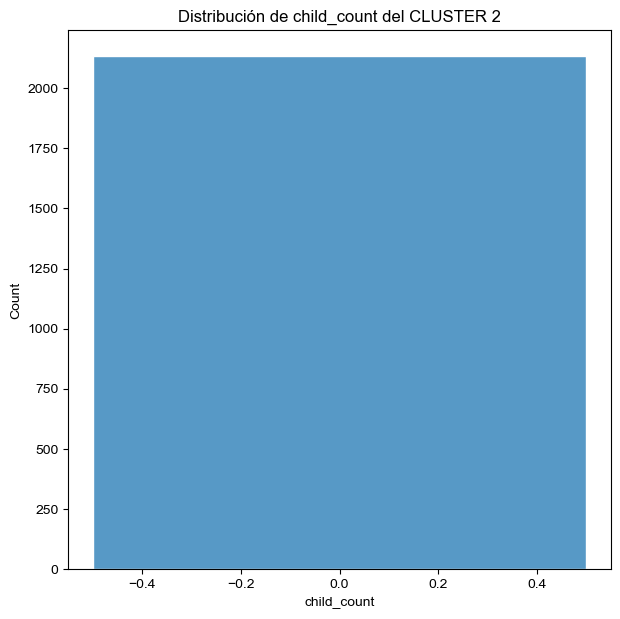

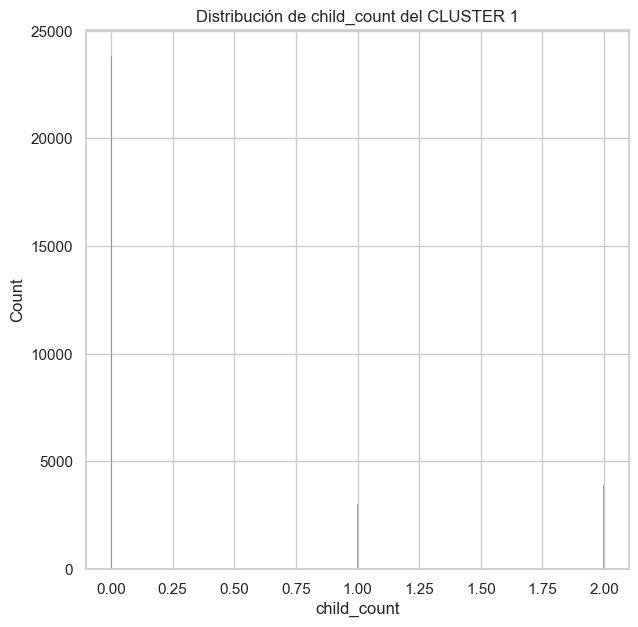

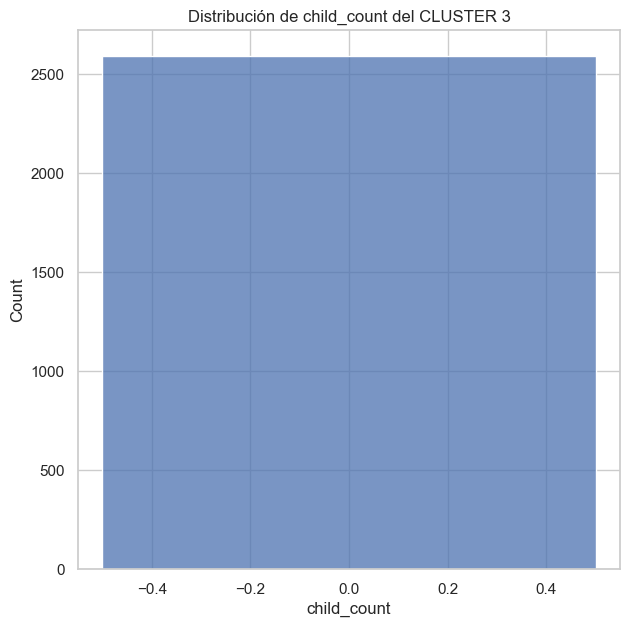

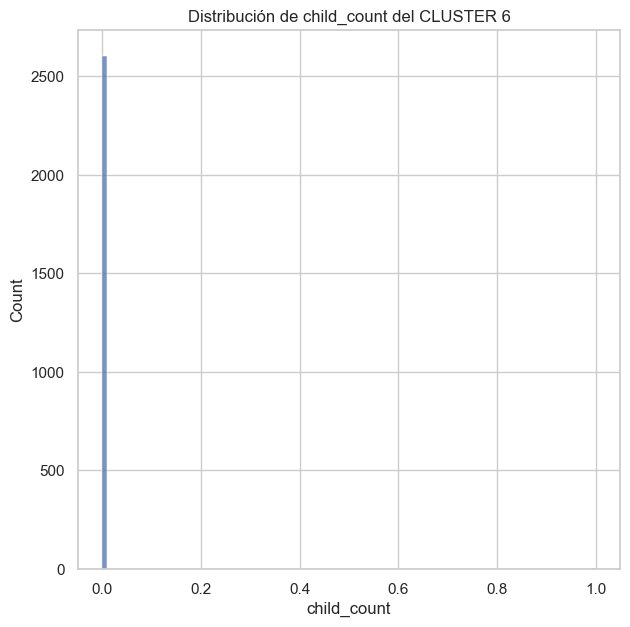

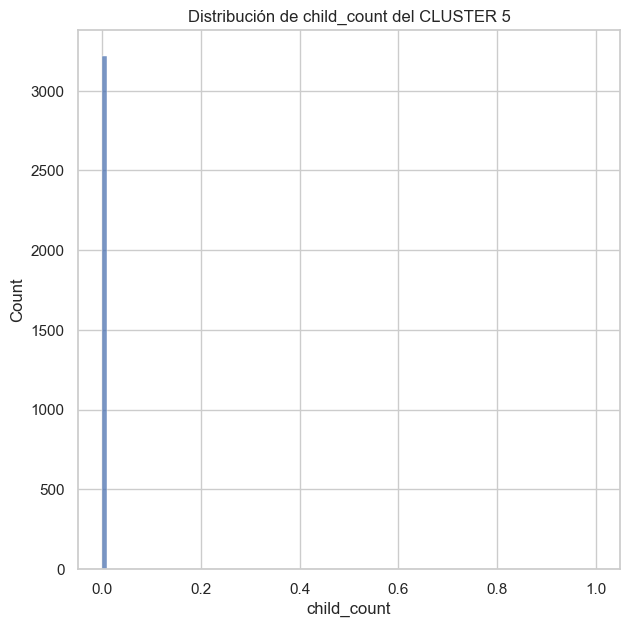

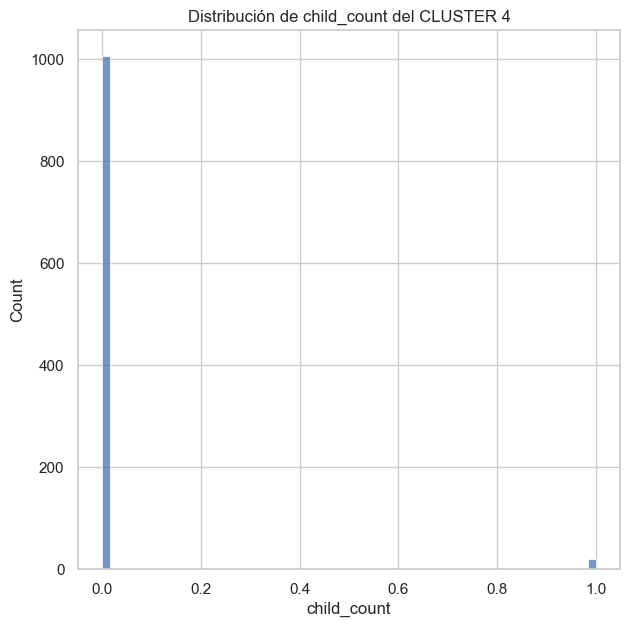

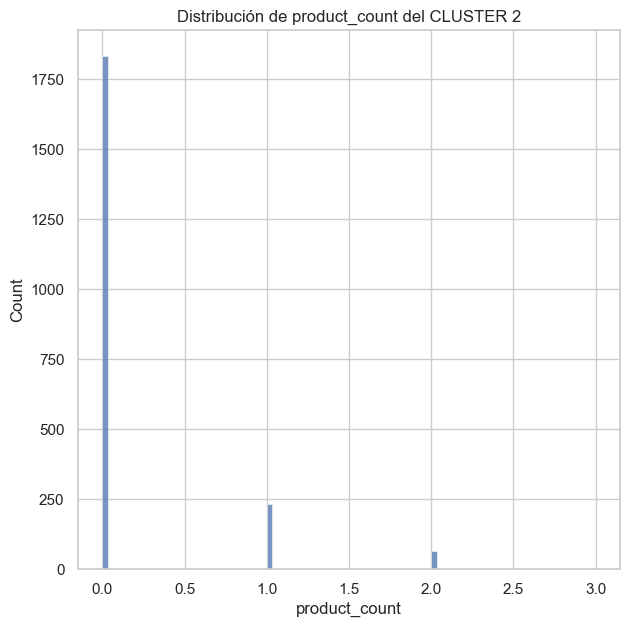

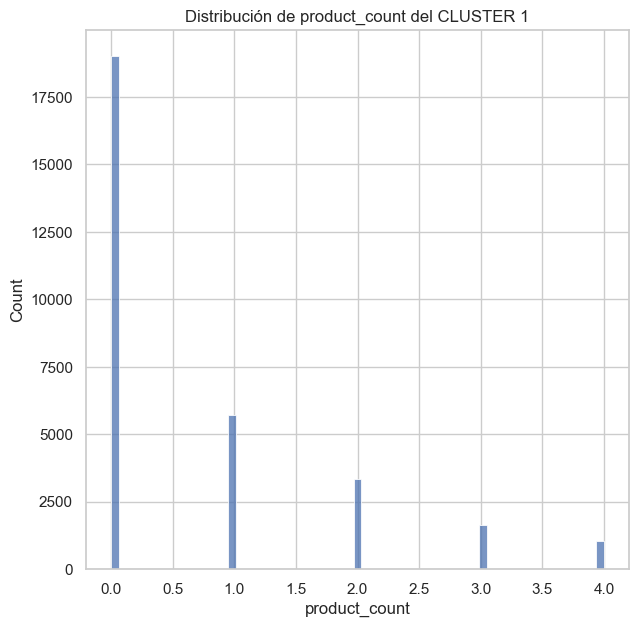

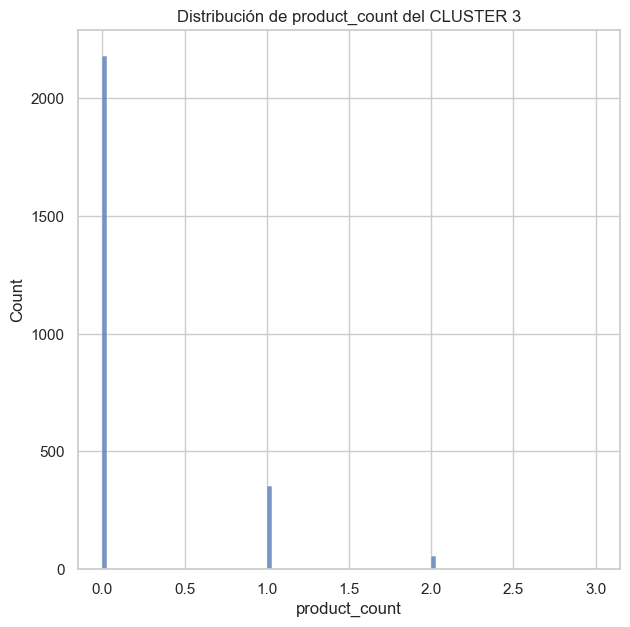

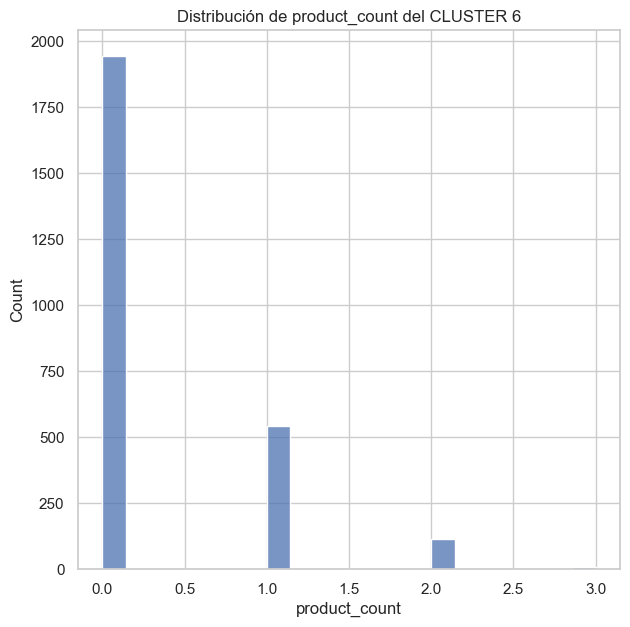

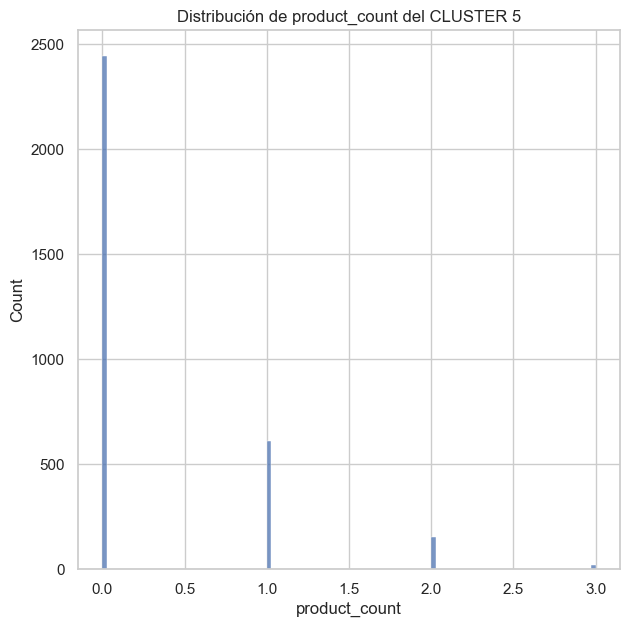

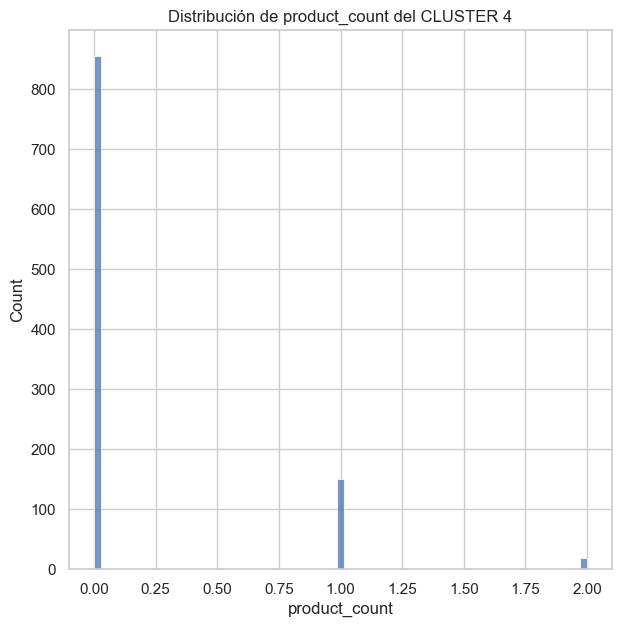

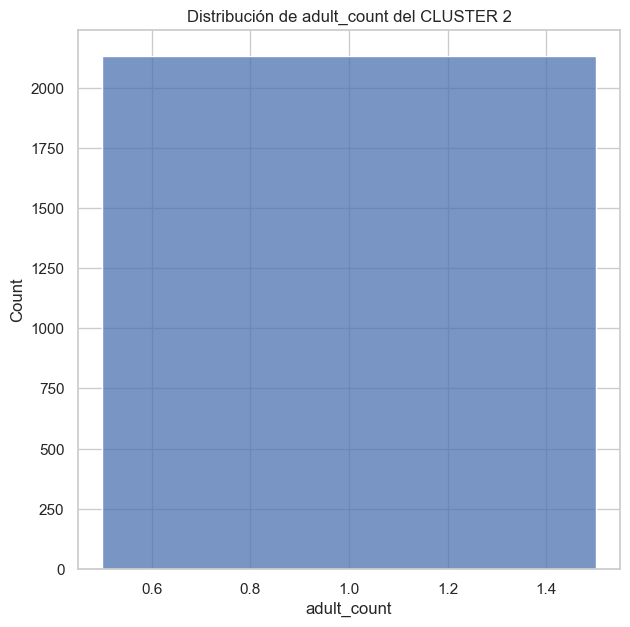

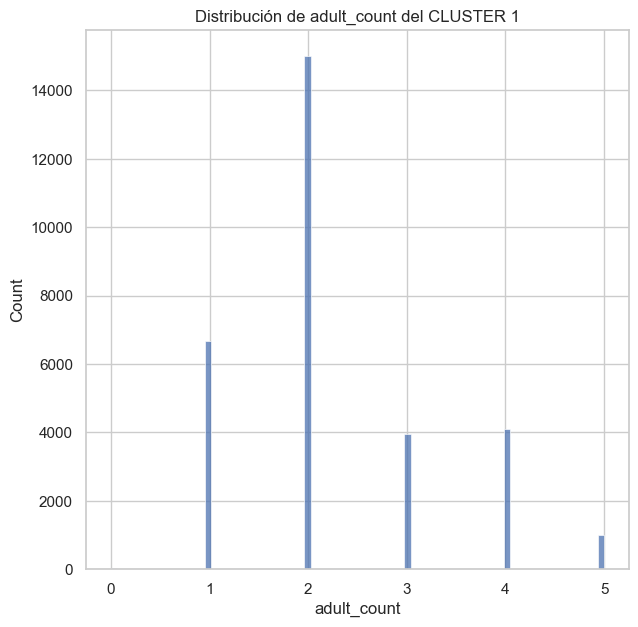

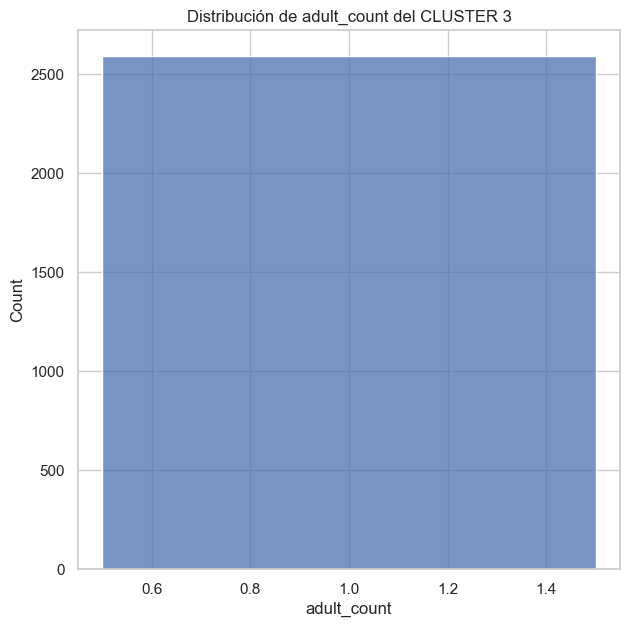

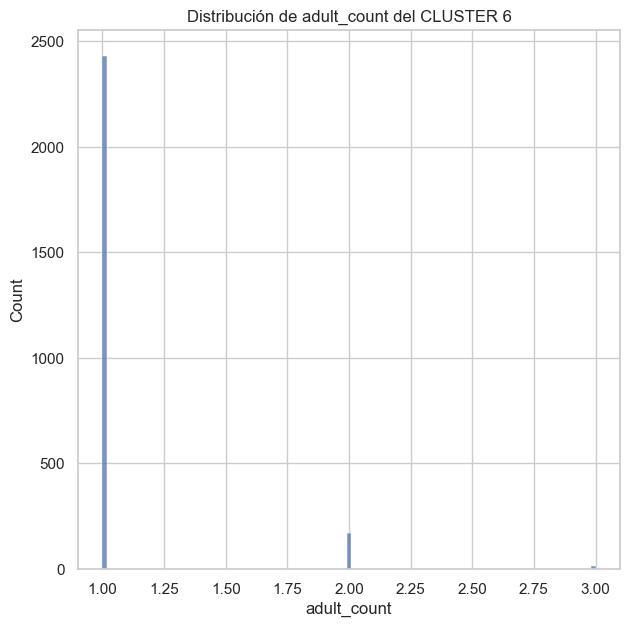

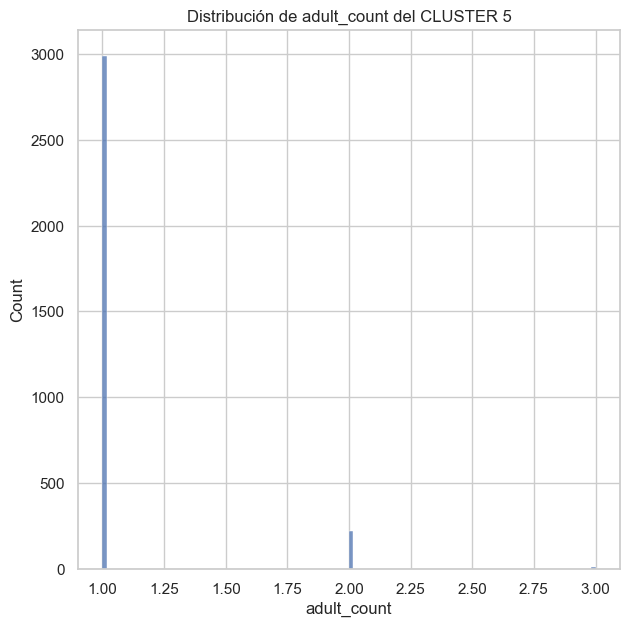

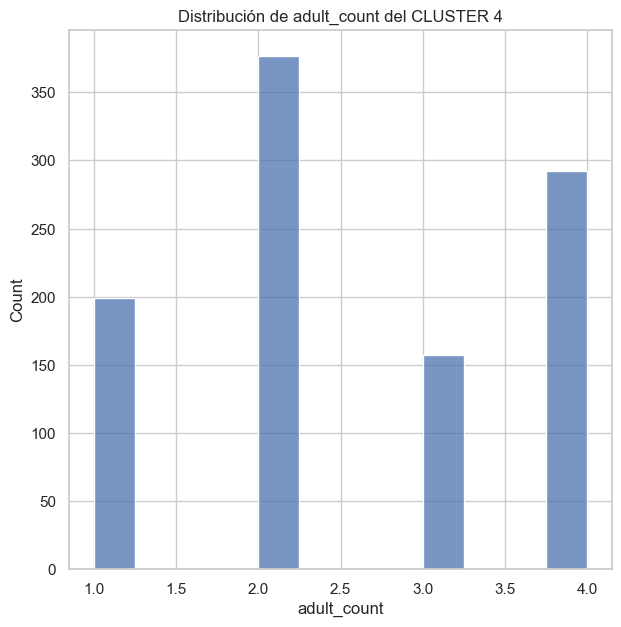

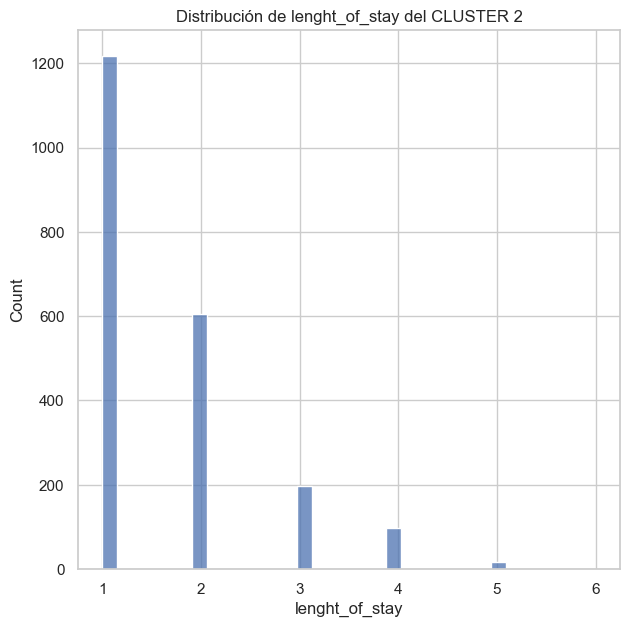

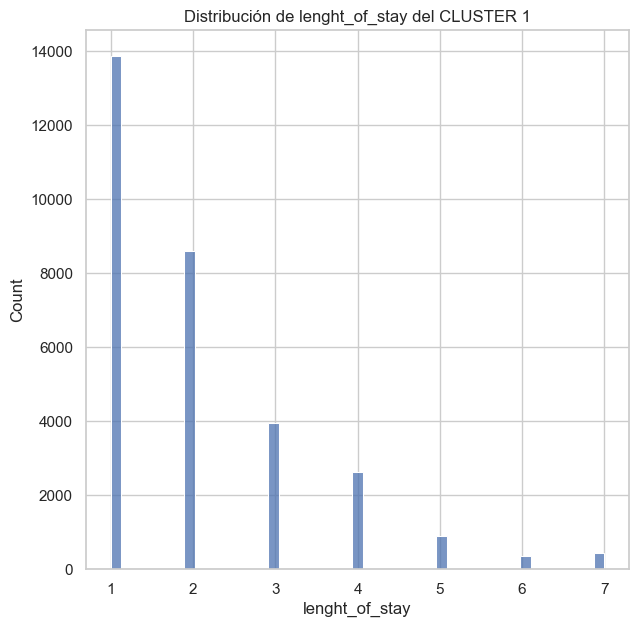

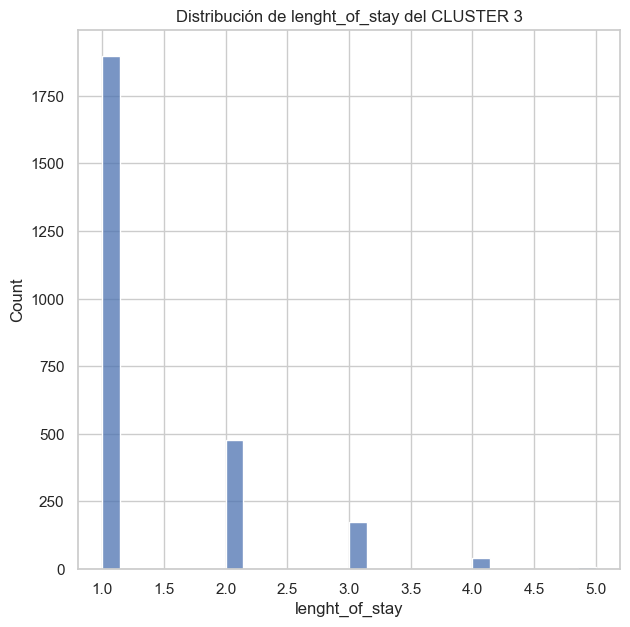

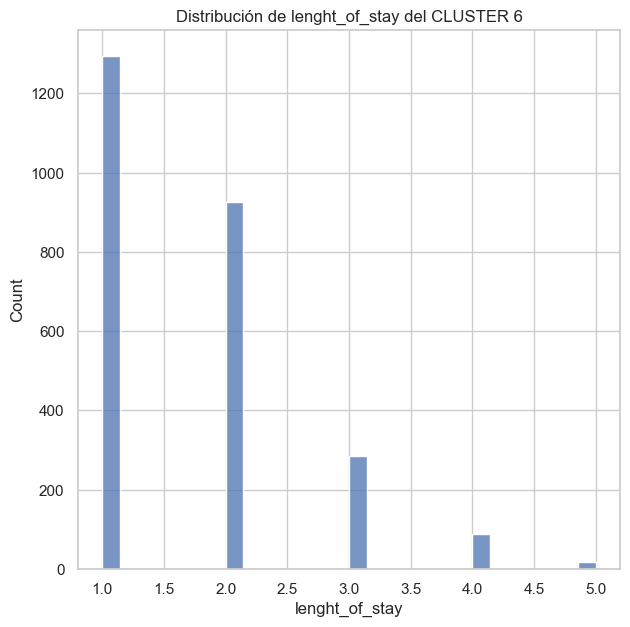

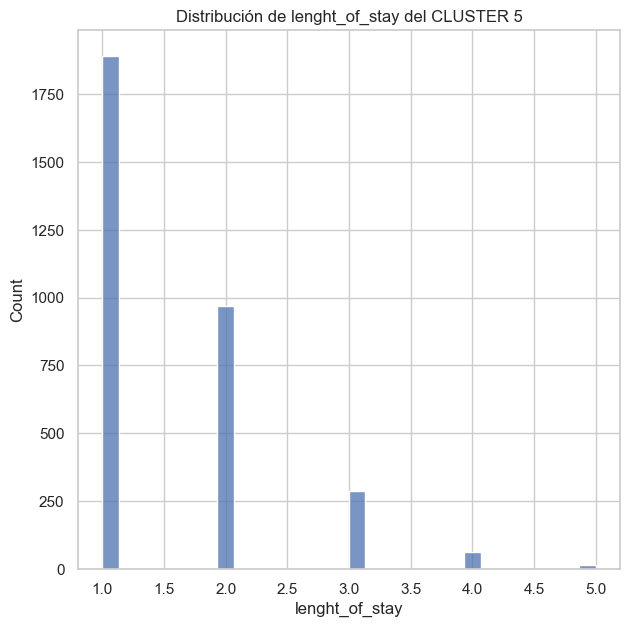

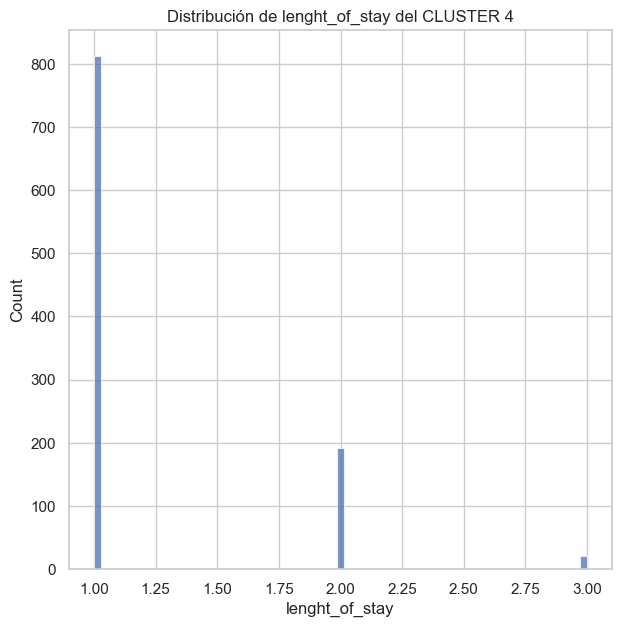

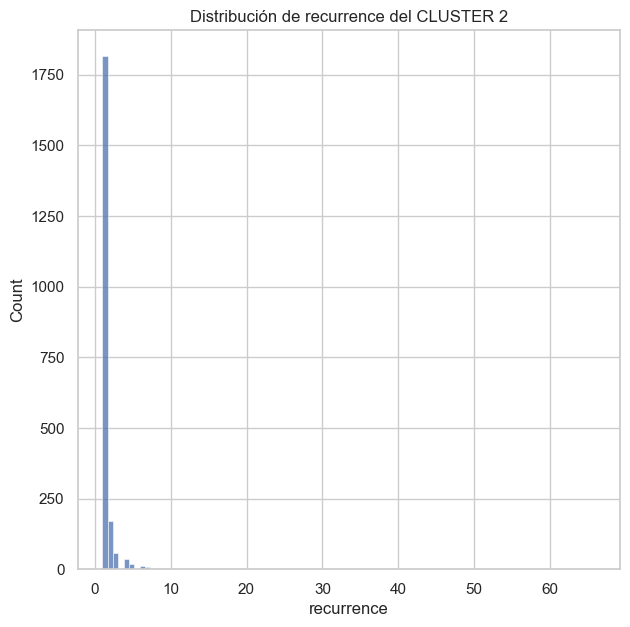

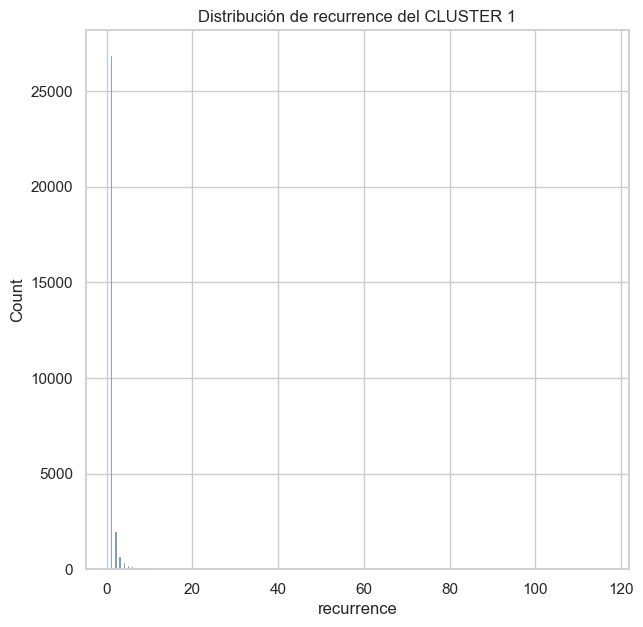

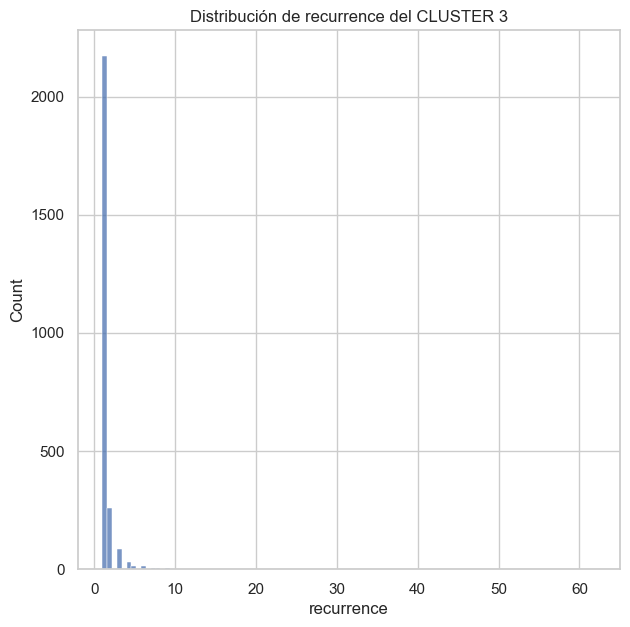

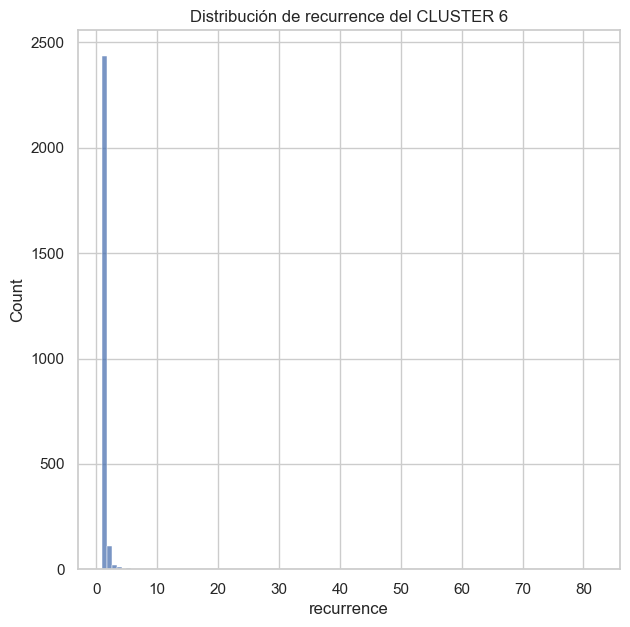

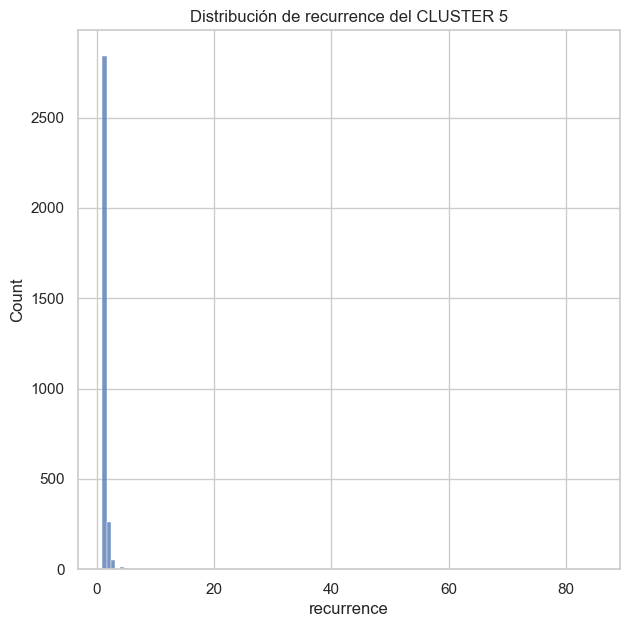

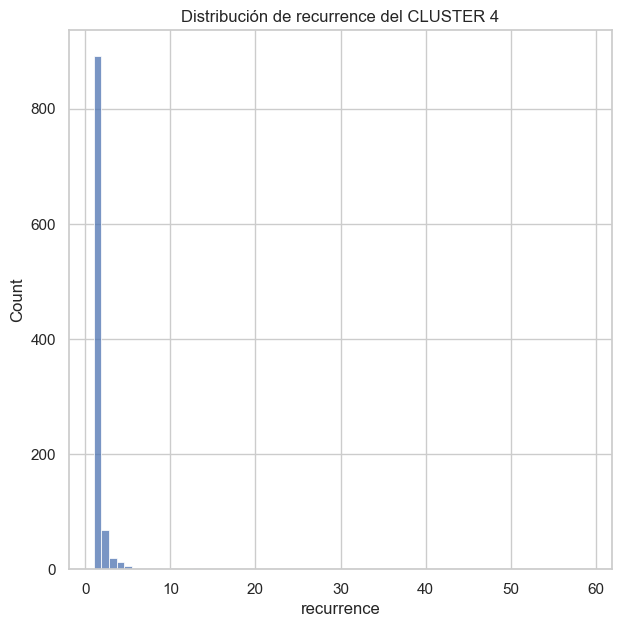

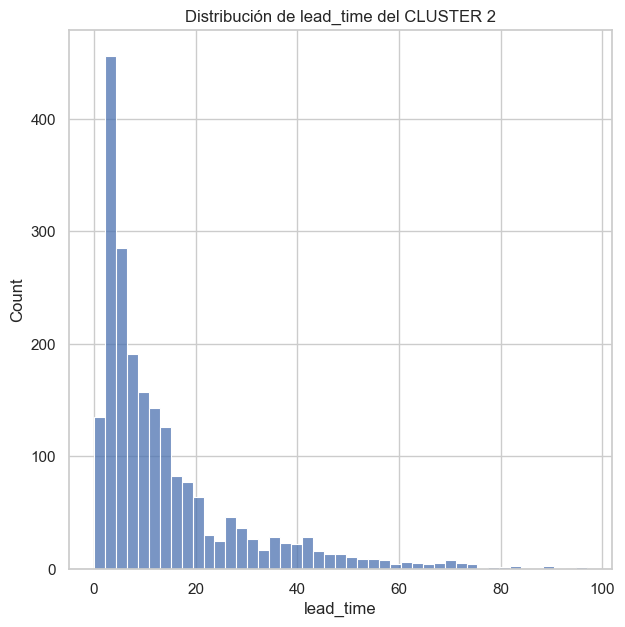

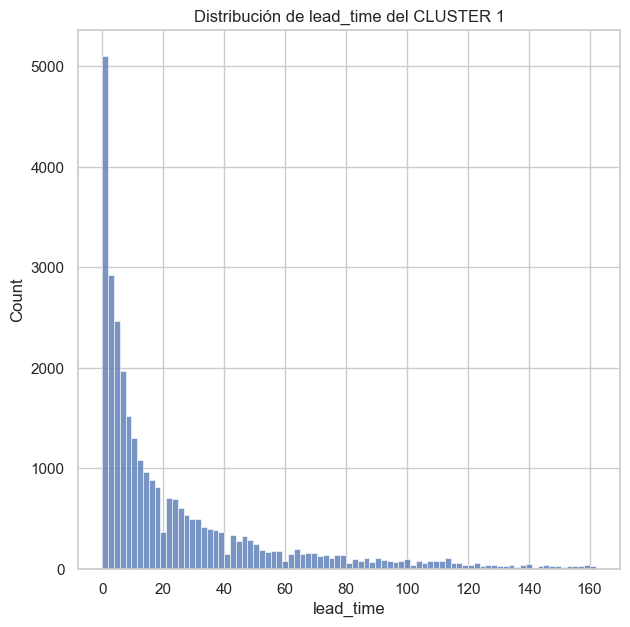

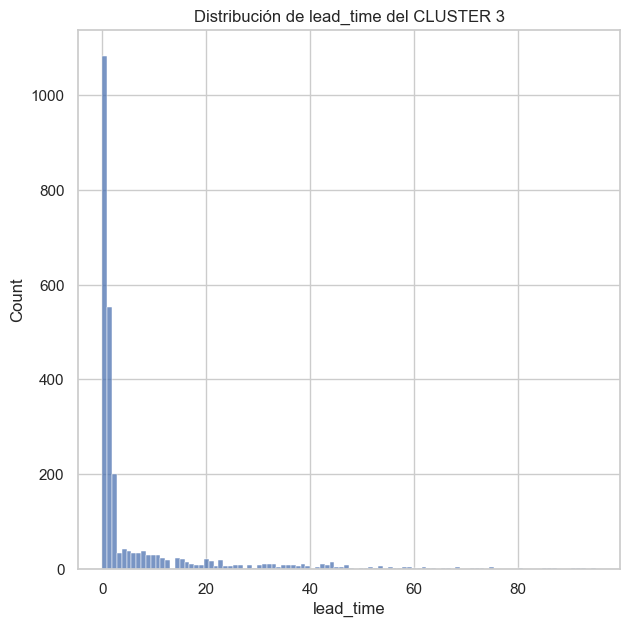

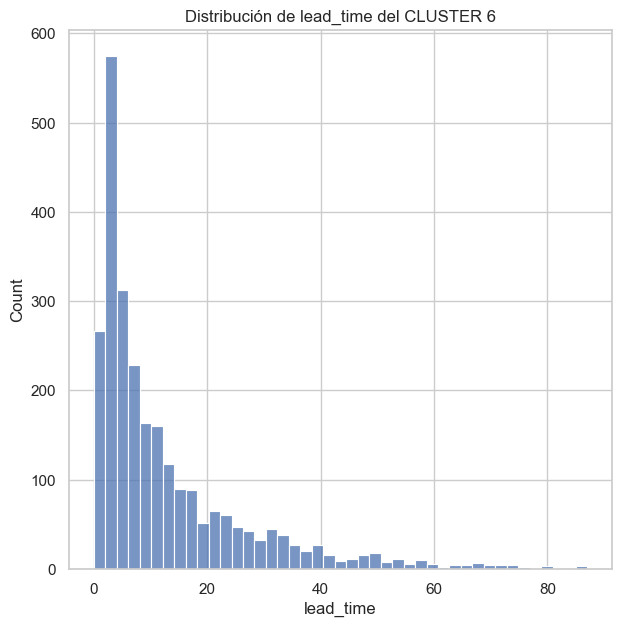

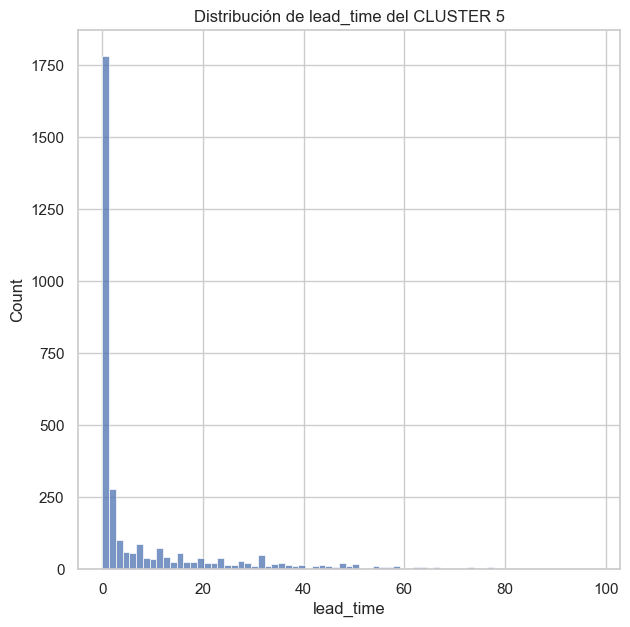

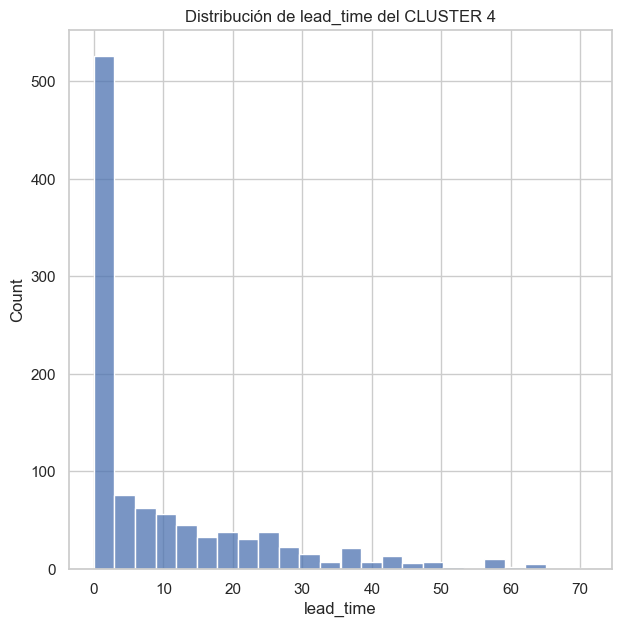

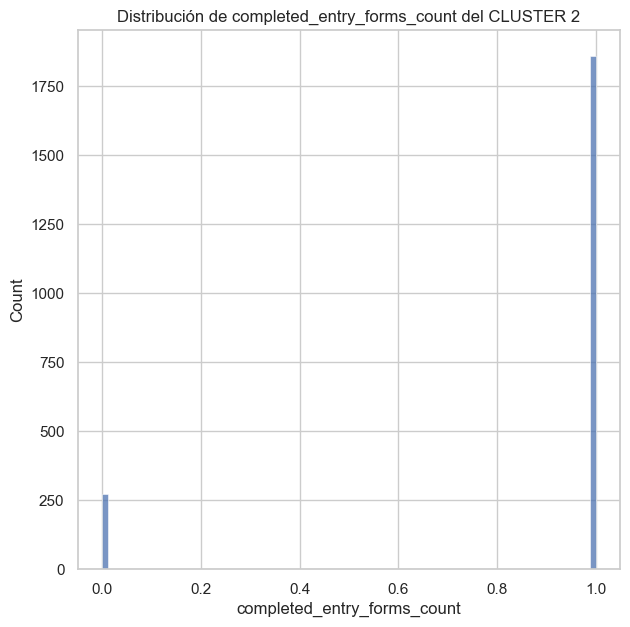

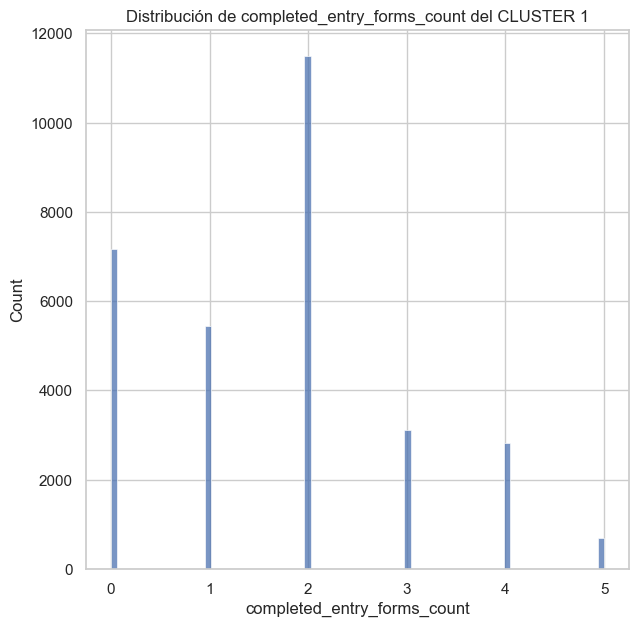

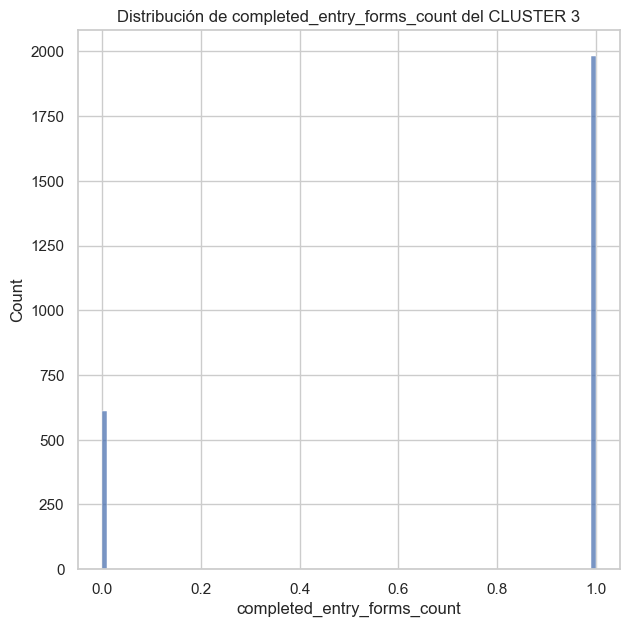

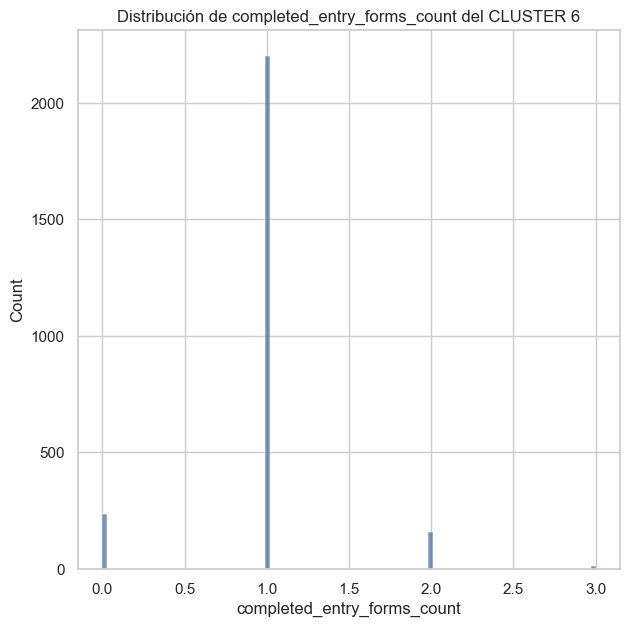

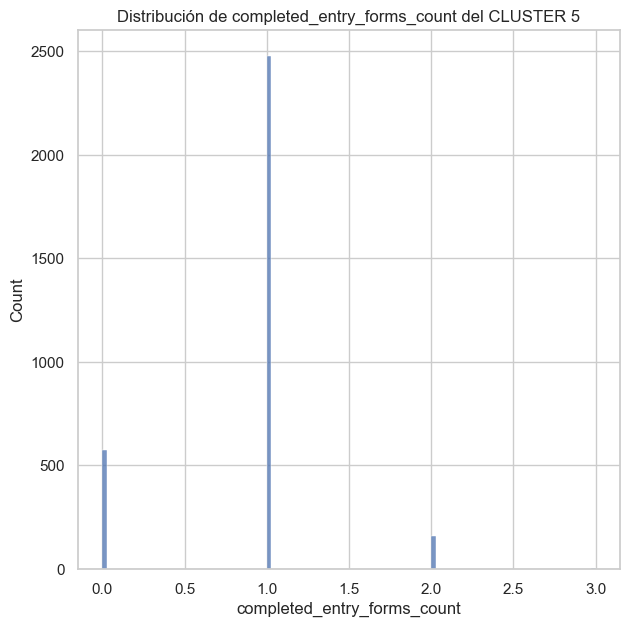

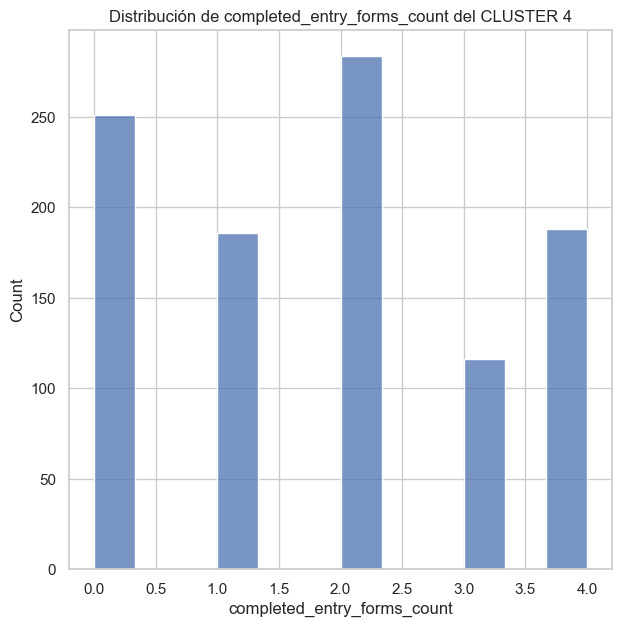

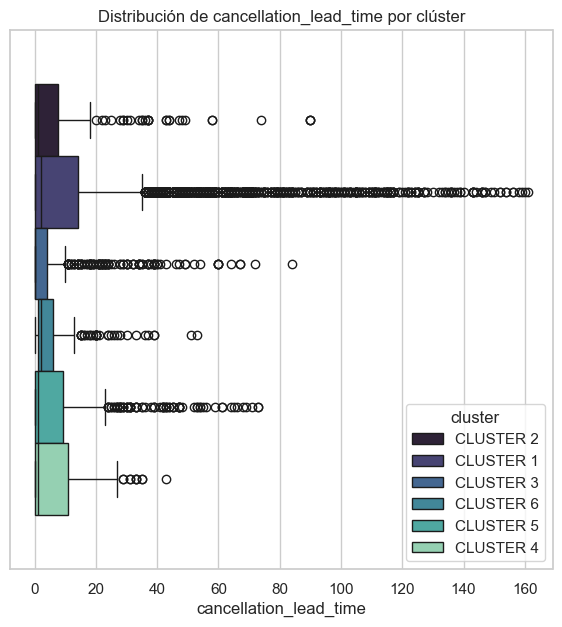

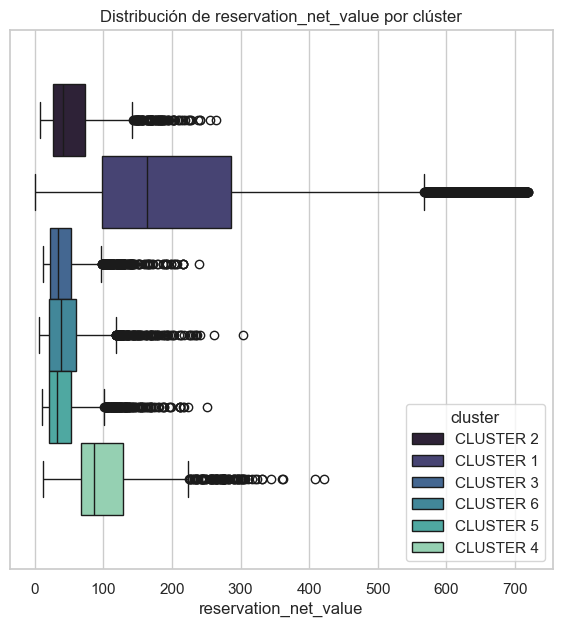

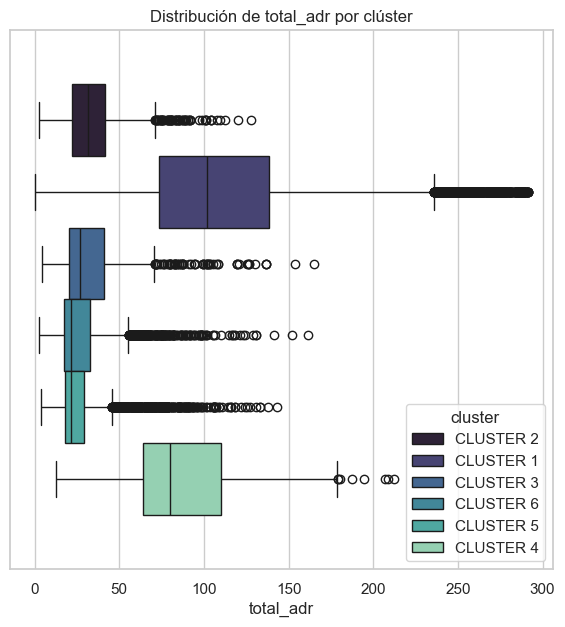

In [4]:
# VARIABLES NUMÉRICAS

centroides_num = pd.DataFrame({'TOTAL': (df[var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 1': (df[df['cluster'] == 'CLUSTER 1'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 2': (df[df['cluster'] == 'CLUSTER 2'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 3': (df[df['cluster'] == 'CLUSTER 3'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 4': (df[df['cluster'] == 'CLUSTER 4'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 5': (df[df['cluster'] == 'CLUSTER 5'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 6': (df[df['cluster'] == 'CLUSTER 6'][var_num].apply(lambda x: np.mean(x)).to_list())})
centroides_num.index = df[df['cluster'] == 'CLUSTER 1'][var_num].apply(lambda x: np.mean(x)).index
centroides_num = centroides_num.reset_index()
centroides_num['VAR'] = centroides_num['index']
del centroides_num['index']

# VARIABLES BOOLEANAS

for var in var_bool:
    df[str(var)] = df[str(var)].map({True: 1, False: 0}).astype('int')
centroides_bool = pd.DataFrame({'TOTAL': (df[var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 1': (df[df['cluster'] == 'CLUSTER 1'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 2': (df[df['cluster'] == 'CLUSTER 2'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 3': (df[df['cluster'] == 'CLUSTER 3'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 4': (df[df['cluster'] == 'CLUSTER 4'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 5': (df[df['cluster'] == 'CLUSTER 5'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 6': (df[df['cluster'] == 'CLUSTER 6'][var_bool].apply(lambda x: np.mean(x)).to_list())})
centroides_bool.index = df[df['cluster'] == 'CLUSTER 1'][var_bool].apply(lambda x: np.mean(x)).index
centroides_bool = centroides_bool.reset_index()
centroides_bool['VAR'] = centroides_bool['index']
del centroides_bool['index']

# VARIABLES CATEGÓRICAS

city = df.groupby(['cluster', 'city']).size().reset_index()
city = city.pivot(index = 'city', columns = 'cluster', values = 0)

asset_type = df.groupby(['cluster', 'asset_type']).size().reset_index()
asset_type = asset_type.pivot(index = 'asset_type', columns = 'cluster', values = 0)

origin = df.groupby(['cluster', 'origin']).size().reset_index()
origin = origin.pivot(index = 'origin', columns = 'cluster', values = 0)

rate_group_name = df.groupby(['cluster', 'rate_group_name']).size().reset_index()
rate_group_name = rate_group_name.pivot(index = 'rate_group_name', columns = 'cluster', values = 0)

checkin_month = df.groupby(['cluster', 'checkin_month']).size().reset_index()
checkin_month = checkin_month.pivot(index = 'checkin_month', columns = 'cluster', values = 0)

cancellation_reason = df.groupby(['cluster', 'cancellation_reason']).size().reset_index()
cancellation_reason = cancellation_reason.pivot(index = 'cancellation_reason', columns = 'cluster', values = 0)

checkin_day = df.groupby(['cluster', 'checkin_day']).size().reset_index()
checkin_day = checkin_day.pivot(index = 'checkin_day', columns = 'cluster', values = 0)

asset = df.groupby(['cluster', 'asset']).size().reset_index()
asset = asset.pivot(index = 'asset', columns = 'cluster', values = 0)

rate_type = df.groupby(['cluster', 'rate_type']).size().reset_index()
rate_type = rate_type.pivot(index = 'rate_type', columns = 'cluster', values = 0)

business_segment = df.groupby(['cluster', 'business_segment']).size().reset_index()
business_segment = business_segment.pivot(index = 'business_segment', columns = 'cluster', values = 0)

# VISUALIZACIONES

for var in var_int:
    for clust in clusters:
        f, ax = plt.subplots(figsize = (7,7))
        sns.set_theme(style="whitegrid")
        paleta_unificada = "mako"
        sns.histplot(data = df[df['cluster'] == clust], x = str(var), palette = paleta_unificada)
        plt.title(f'Distribución de {var} del {clust}')
        plt.savefig(os.path.join('Graficos', 'Clusterizacion', f'histograma_{var}_{clust}.png'))

for var in var_flo:
    f, ax = plt.subplots(figsize = (7,7))
    sns.set_theme(style="whitegrid")
    paleta_unificada = "mako"
    sns.boxplot(data = df, x = str(var), hue = 'cluster', palette = paleta_unificada)
    plt.title(f'Distribución de {var} por clúster')
    plt.savefig(os.path.join('Graficos', 'Clusterizacion', f'boxplot_{var}_clusters.png'))



In [5]:
# # PERFIL DE LOS QUE CANCELAN

cancelados = df[df['is_cancelled'] == 1]

cancelados_num = pd.DataFrame({'TOTAL': (cancelados[var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 1': (cancelados[cancelados['cluster'] == 'CLUSTER 1'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 2': (cancelados[cancelados['cluster'] == 'CLUSTER 2'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 3': (cancelados[cancelados['cluster'] == 'CLUSTER 3'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 4': (cancelados[cancelados['cluster'] == 'CLUSTER 4'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 5': (cancelados[cancelados['cluster'] == 'CLUSTER 5'][var_num].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 6': (cancelados[cancelados['cluster'] == 'CLUSTER 6'][var_num].apply(lambda x: np.mean(x)).to_list())})
cancelados_num.index = cancelados[cancelados['cluster'] == 'CLUSTER 1'][var_num].apply(lambda x: np.mean(x)).index
cancelados_num = cancelados_num.reset_index()
cancelados_num['VAR'] = cancelados_num['index']
del cancelados_num['index']

cancelados_bool = pd.DataFrame({'TOTAL': (cancelados[var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 1': (cancelados[cancelados['cluster'] == 'CLUSTER 1'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 2': (cancelados[cancelados['cluster'] == 'CLUSTER 2'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 3': (cancelados[cancelados['cluster'] == 'CLUSTER 3'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 4': (cancelados[cancelados['cluster'] == 'CLUSTER 4'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 5': (cancelados[cancelados['cluster'] == 'CLUSTER 5'][var_bool].apply(lambda x: np.mean(x)).to_list()),
              'CLUSTER 6': (cancelados[cancelados['cluster'] == 'CLUSTER 6'][var_bool].apply(lambda x: np.mean(x)).to_list())})
cancelados_bool.index = cancelados[cancelados['cluster'] == 'CLUSTER 1'][var_bool].apply(lambda x: np.mean(x)).index
cancelados_bool = cancelados_bool.reset_index()
cancelados_bool['VAR'] = cancelados_bool['index']
del cancelados_bool['index']

cancelados_city = cancelados.groupby(['cluster', 'city']).size().reset_index()
cancelados_city = cancelados_city.pivot(index = 'city', columns = 'cluster', values = 0)

cancelados_asset_type = cancelados.groupby(['cluster', 'asset_type']).size().reset_index()
cancelados_asset_type = cancelados_asset_type.pivot(index = 'asset_type', columns = 'cluster', values = 0)

cancelados_origin = cancelados.groupby(['cluster', 'origin']).size().reset_index()
cancelados_origin = cancelados_origin.pivot(index = 'origin', columns = 'cluster', values = 0)

cancelados_rate_group_name = cancelados.groupby(['cluster', 'rate_group_name']).size().reset_index()
cancelados_rate_group_name = cancelados_rate_group_name.pivot(index = 'rate_group_name', columns = 'cluster', values = 0)

cancelados_checkin_month = cancelados.groupby(['cluster', 'checkin_month']).size().reset_index()
cancelados_checkin_month = cancelados_checkin_month.pivot(index = 'checkin_month', columns = 'cluster', values = 0)

cancelados_cancellation_reason = cancelados.groupby(['cluster', 'cancellation_reason']).size().reset_index()
cancelados_cancellation_reason = cancelados_cancellation_reason.pivot(index = 'cancellation_reason', columns = 'cluster', values = 0)

cancelados_checkin_day = cancelados.groupby(['cluster', 'checkin_day']).size().reset_index()
cancelados_checkin_day = cancelados_checkin_day.pivot(index = 'checkin_day', columns = 'cluster', values = 0)

cancelados_asset = cancelados.groupby(['cluster', 'asset']).size().reset_index()
cancelados_asset = cancelados_asset.pivot(index = 'asset', columns = 'cluster', values = 0)

cancelados_rate_type = cancelados.groupby(['cluster', 'rate_type']).size().reset_index()
cancelados_rate_type = cancelados_rate_type.pivot(index = 'rate_type', columns = 'cluster', values = 0)

cancelados_business_segment = cancelados.groupby(['cluster', 'business_segment']).size().reset_index()
cancelados_business_segment = cancelados_business_segment.pivot(index = 'business_segment', columns = 'cluster', values = 0)



C:\Users\danie\AppData\Local\Temp\ipykernel_23592\727581523.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = cancelados[cancelados['cluster'] == clust], x = str(var), palette = paleta_unificada)
C:\Users\danie\AppData\Local\Temp\ipykernel_23592\727581523.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = cancelados[cancelados['cluster'] == clust], x = str(var), palette = paleta_unificada)
C:\Users\danie\AppData\Local\Temp\ipykernel_23592\727581523.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = cancelados[cancelados['cluster'] == clust], x = str(var), palette = paleta_unificada)
C:\Users\danie\AppData\Local\Temp\ipykernel_23592\727581523.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = cancelados[cancelados['cluster'] == clust], x = str(var), palette = paleta_unifica

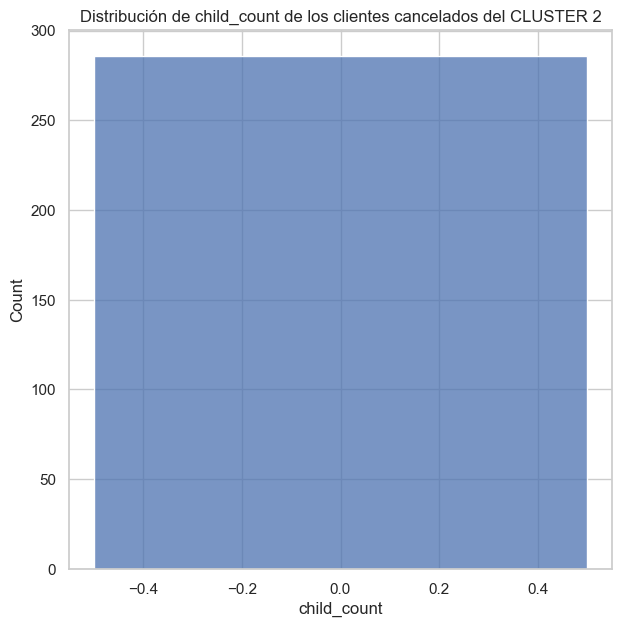

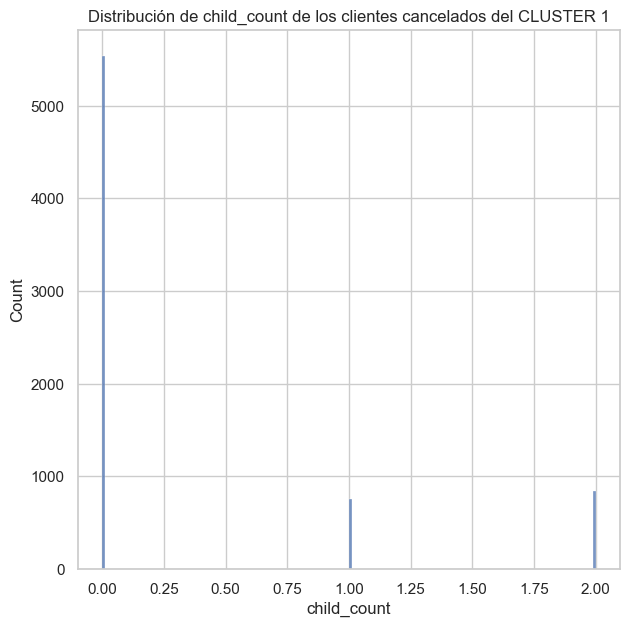

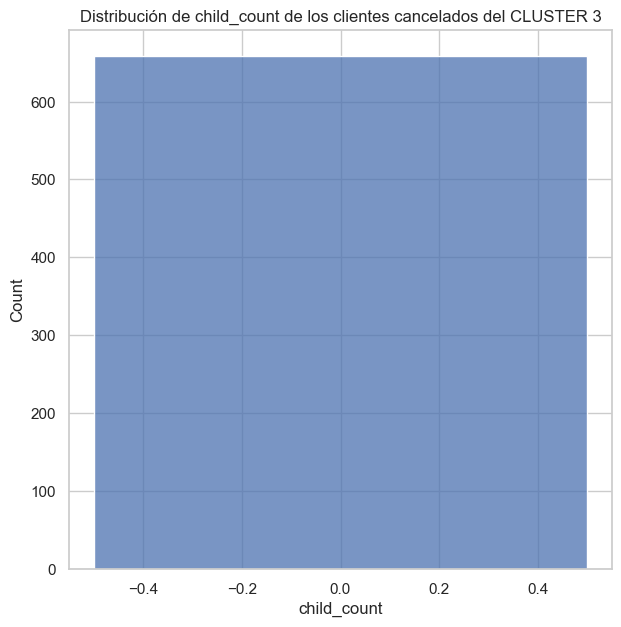

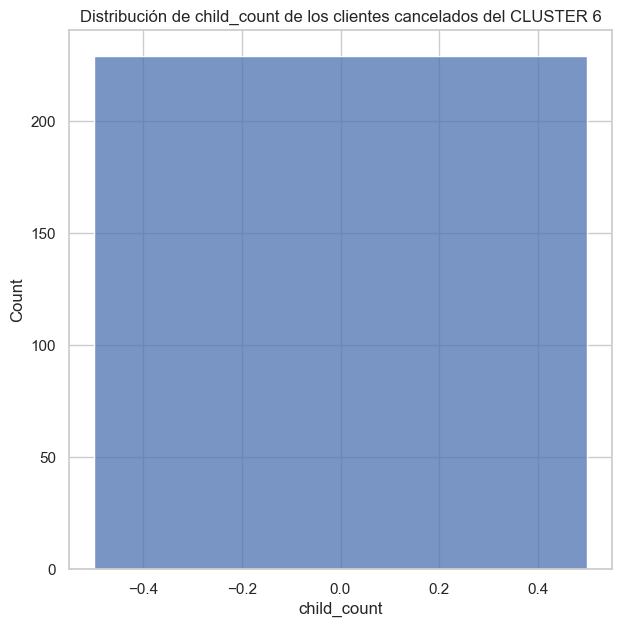

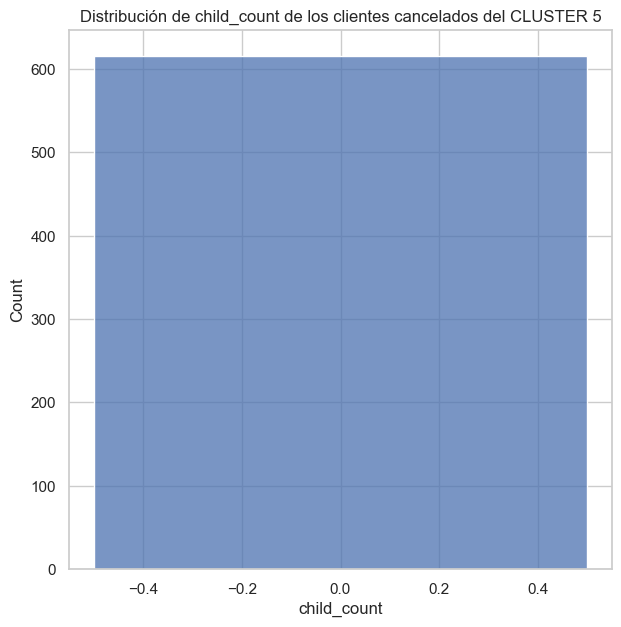

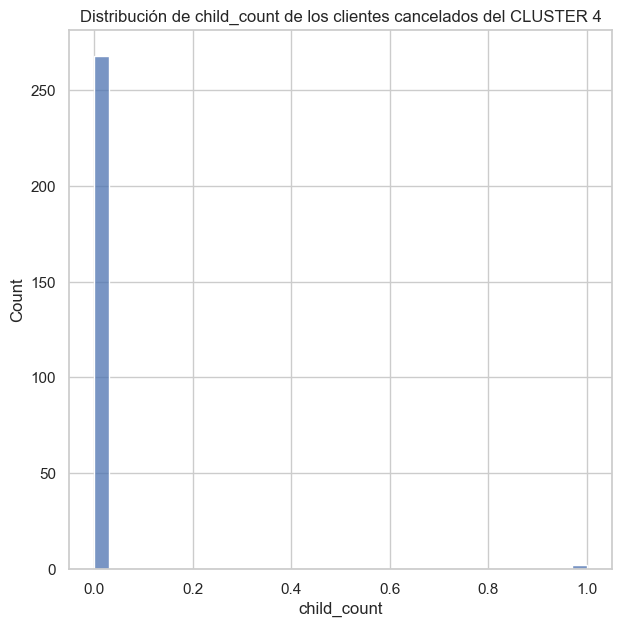

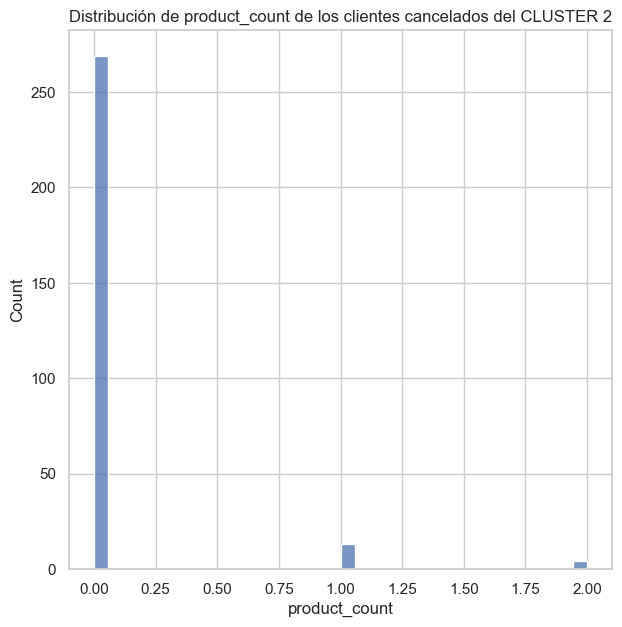

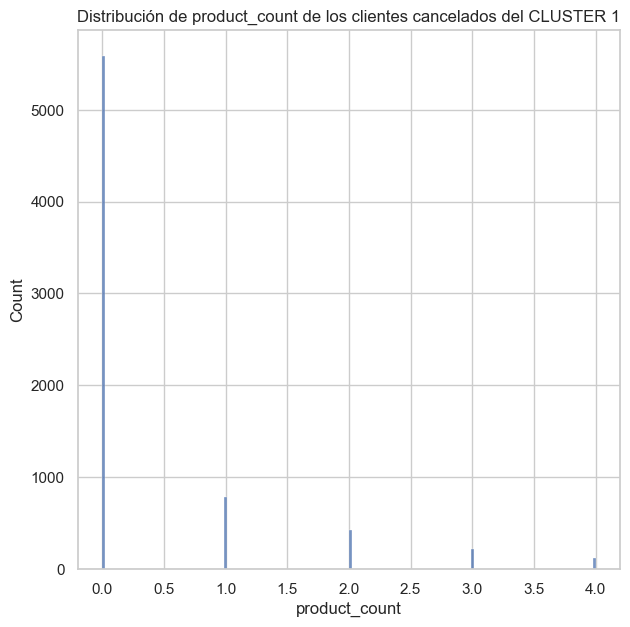

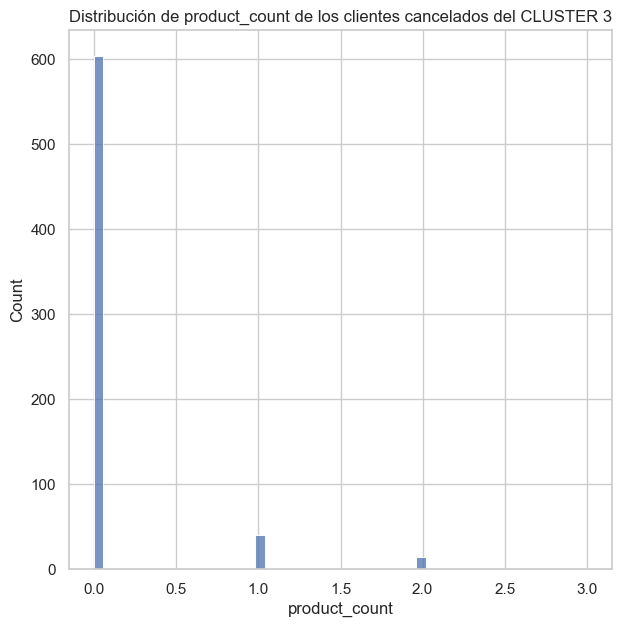

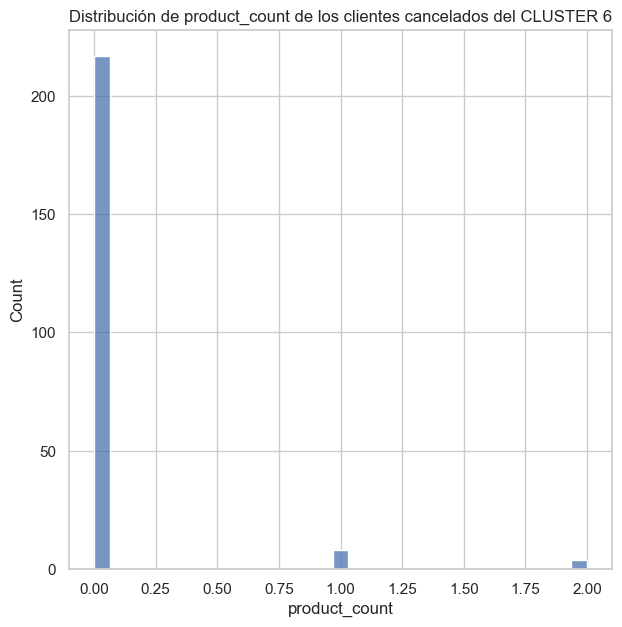

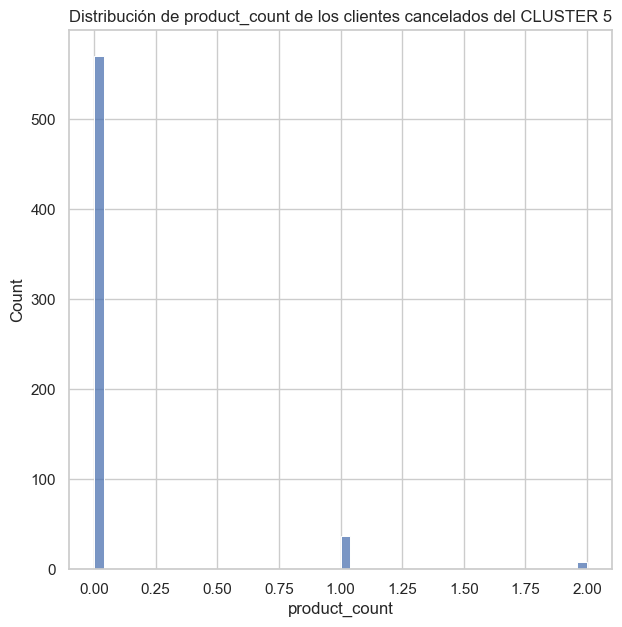

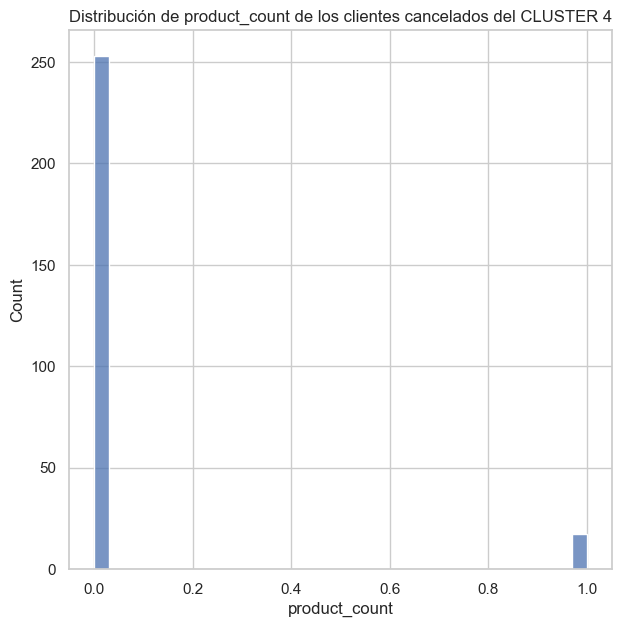

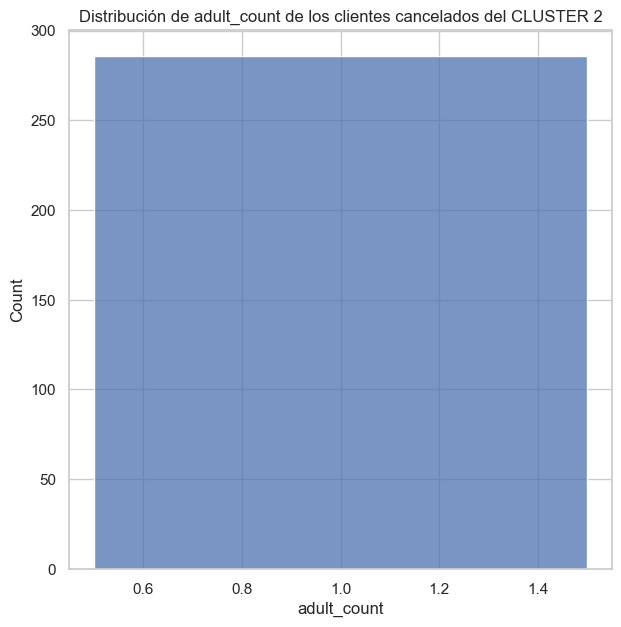

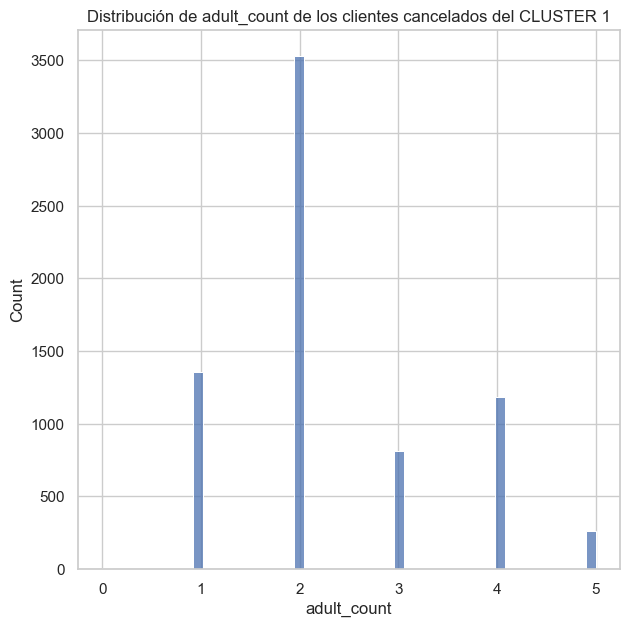

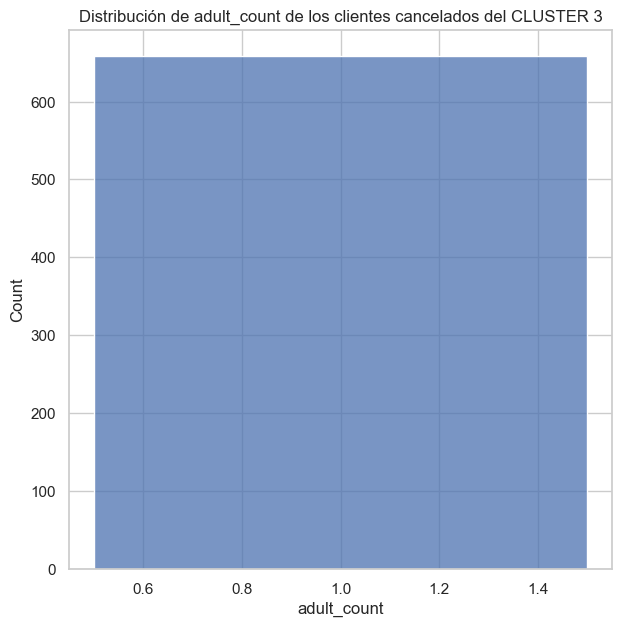

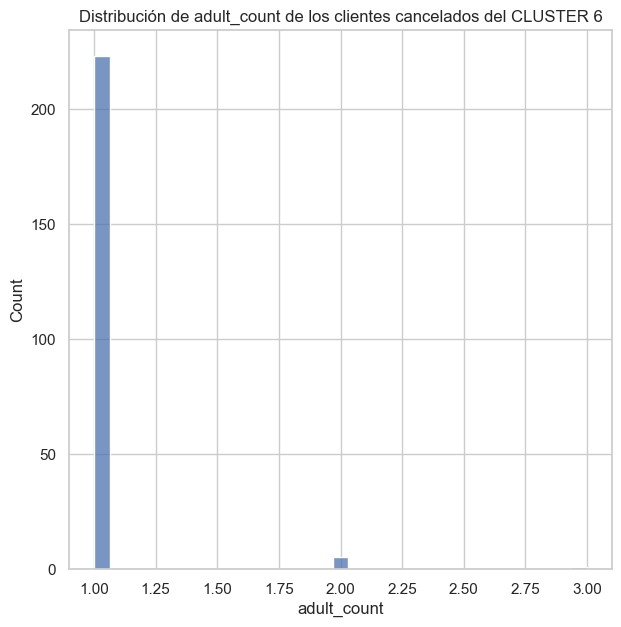

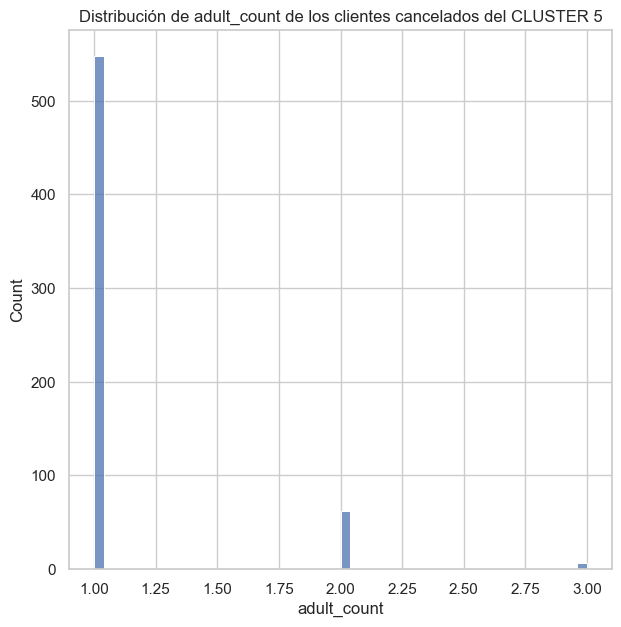

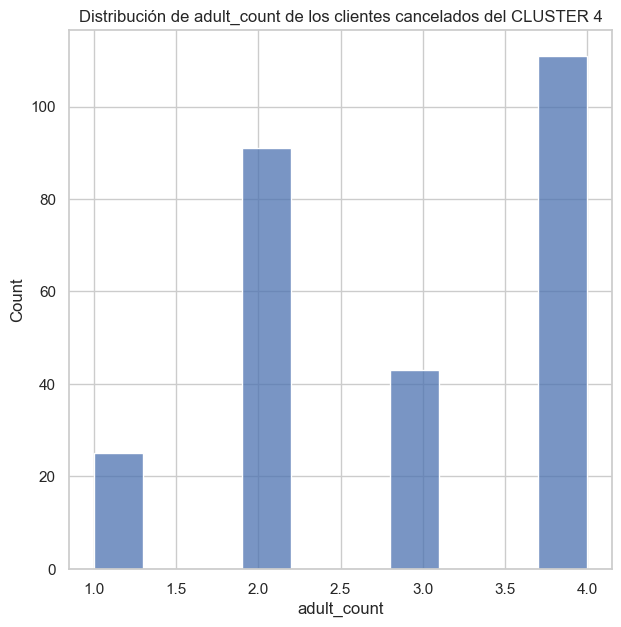

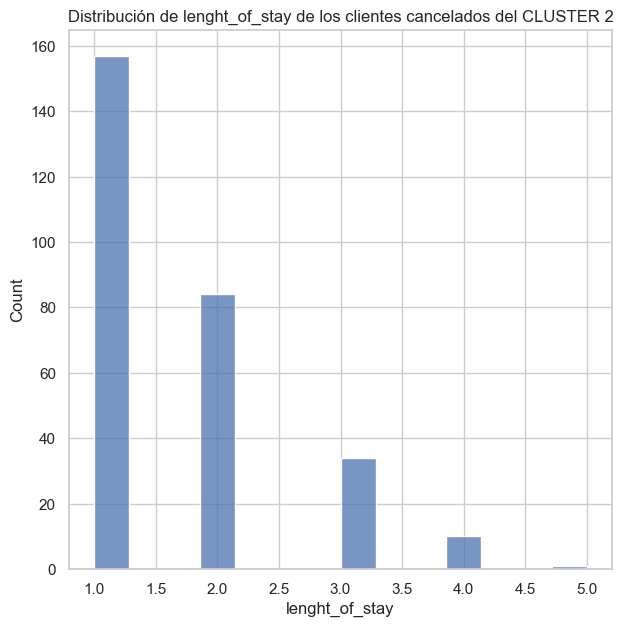

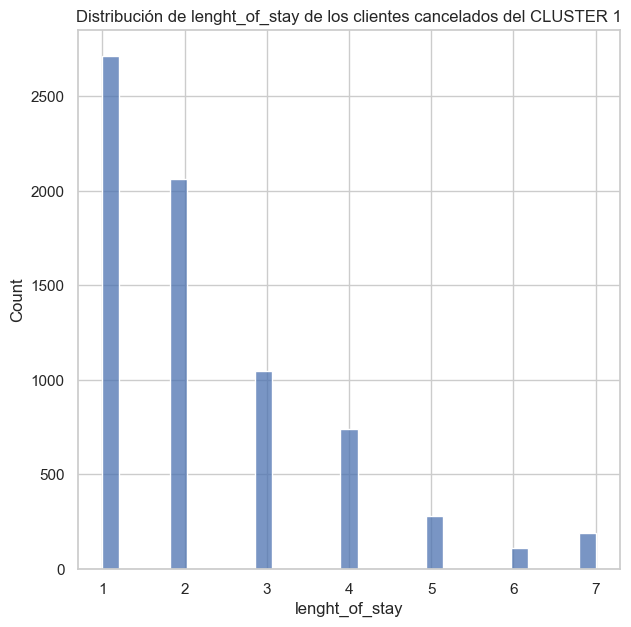

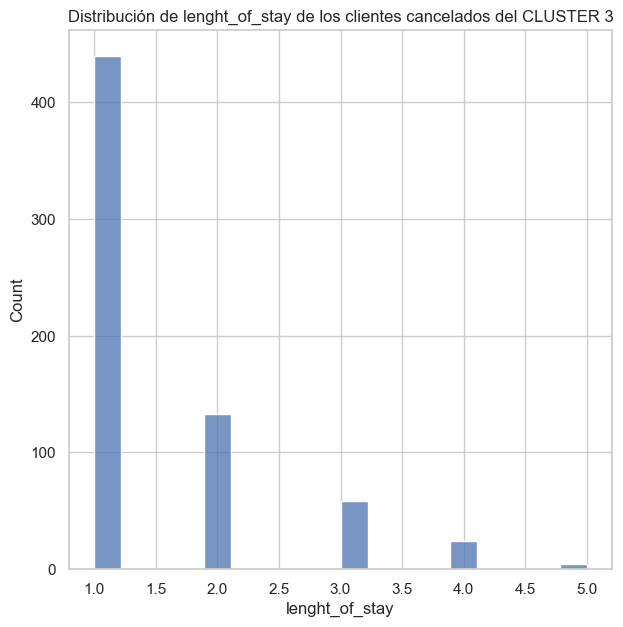

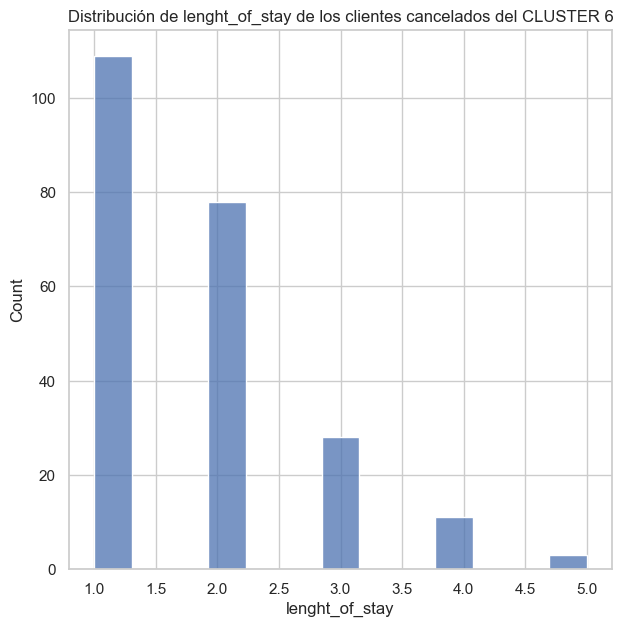

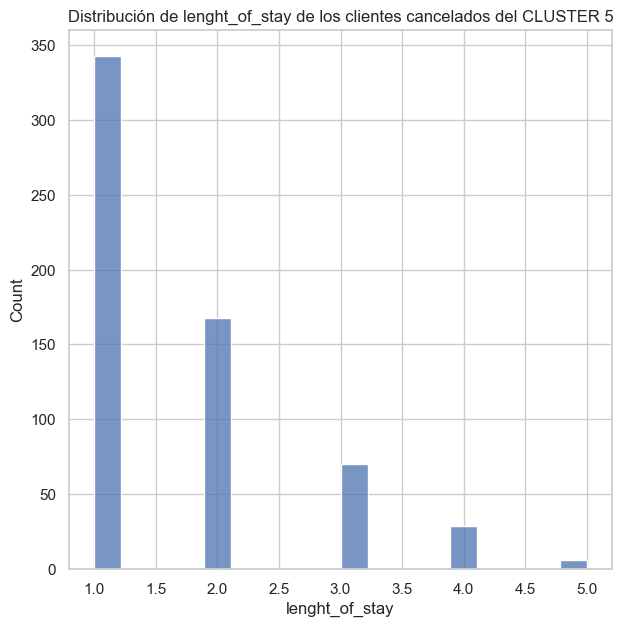

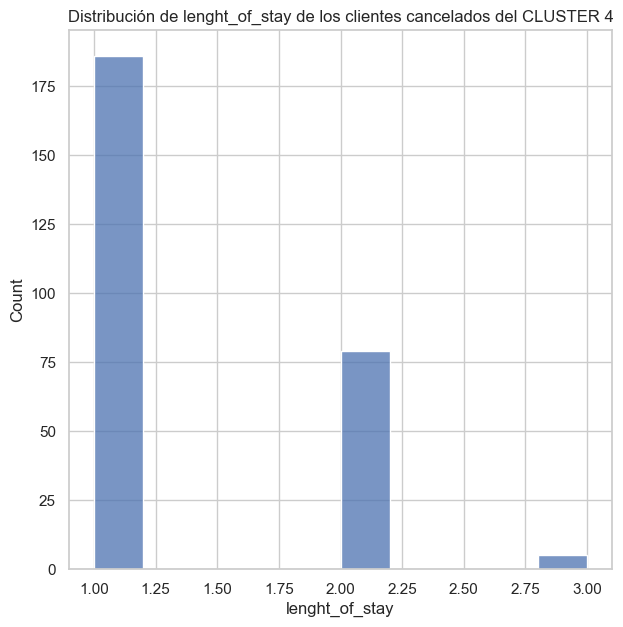

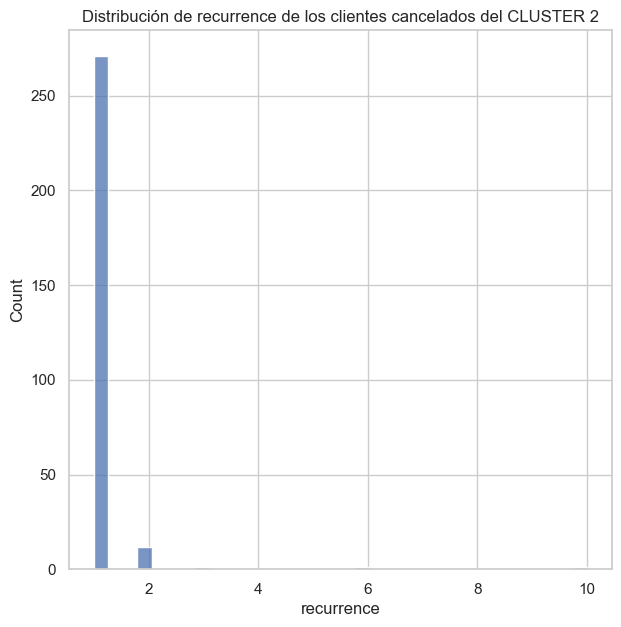

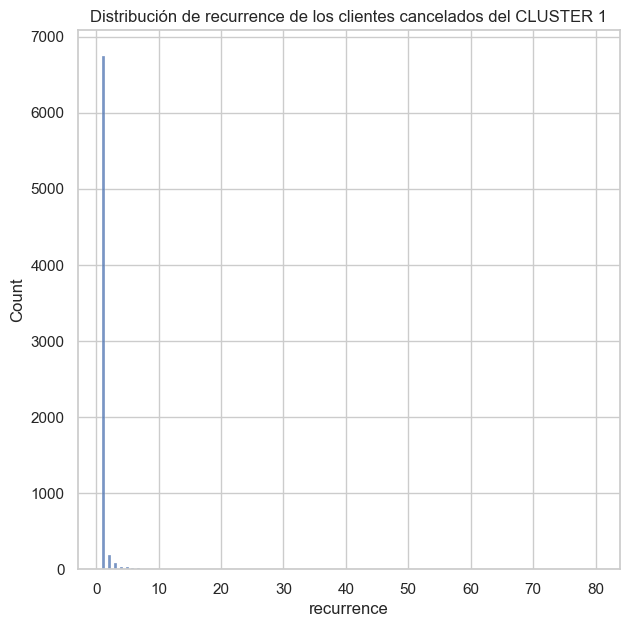

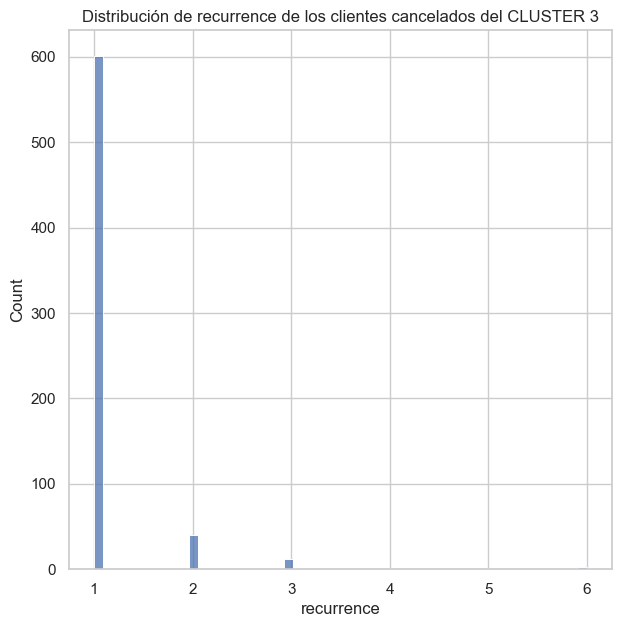

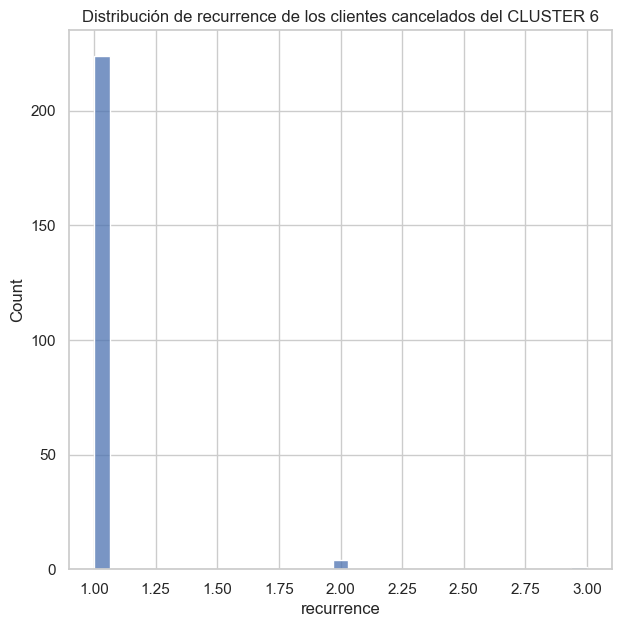

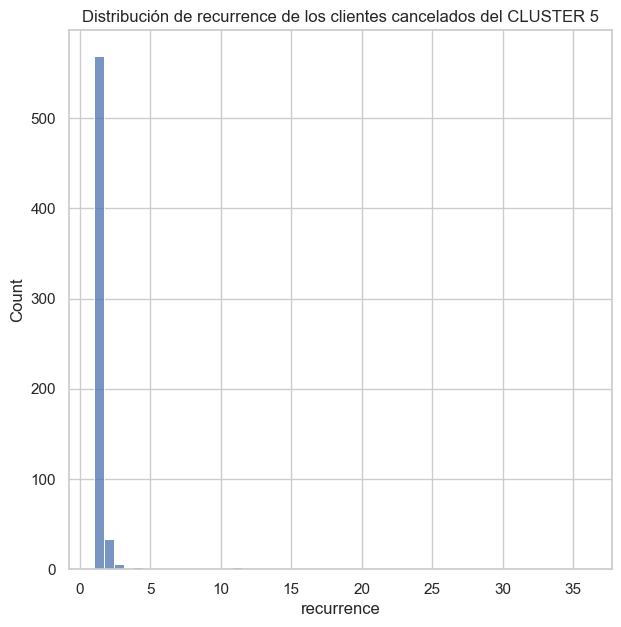

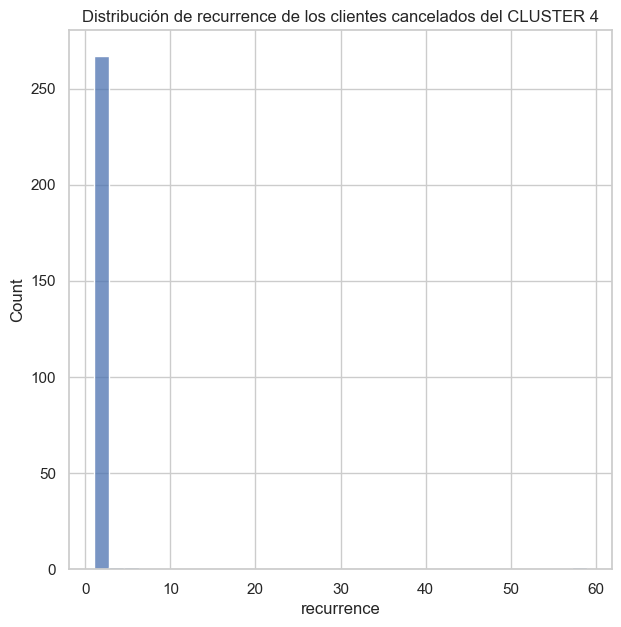

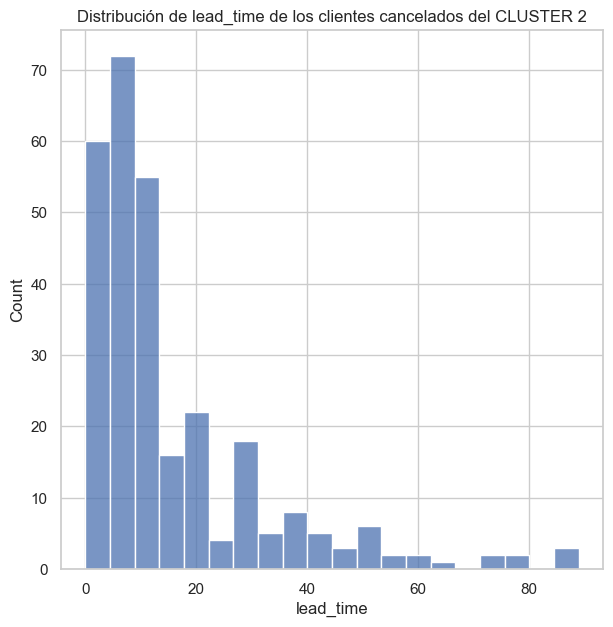

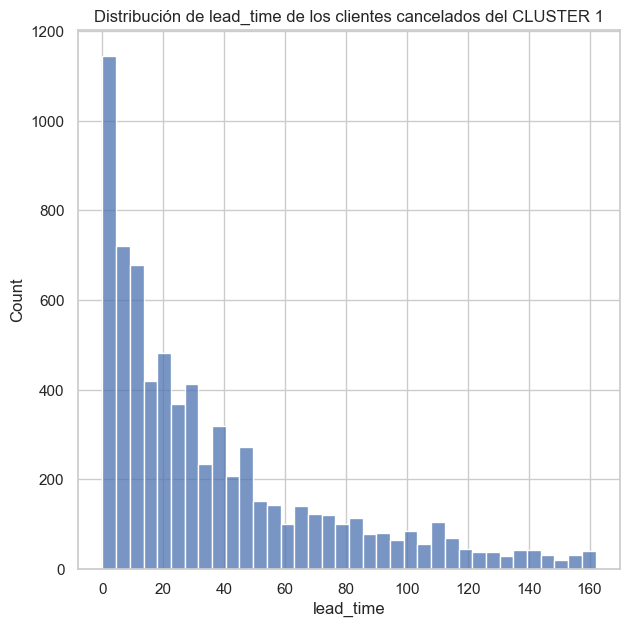

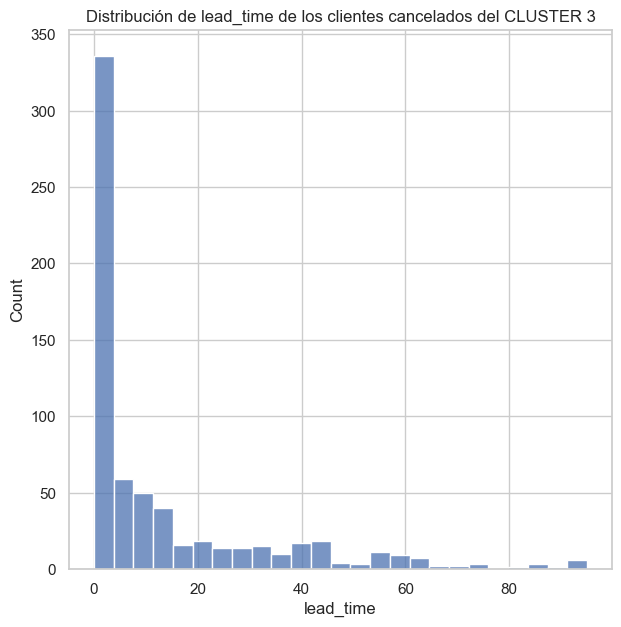

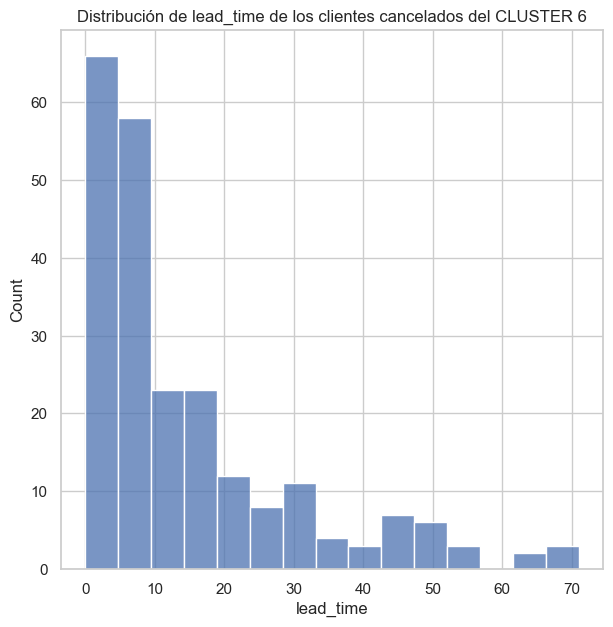

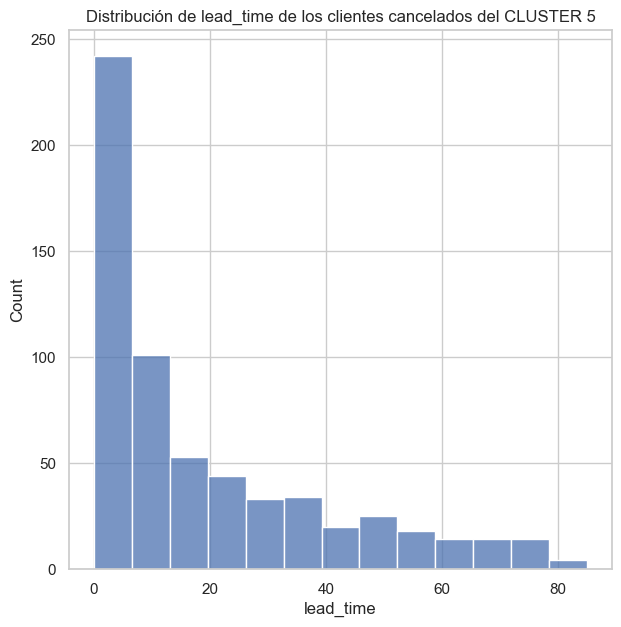

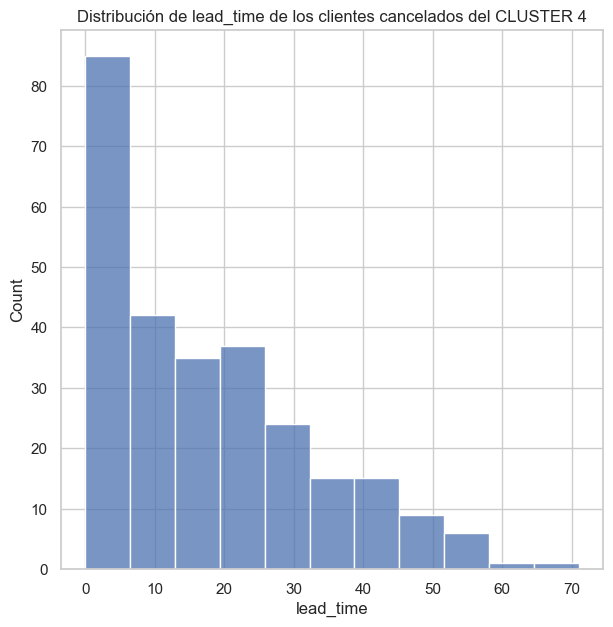

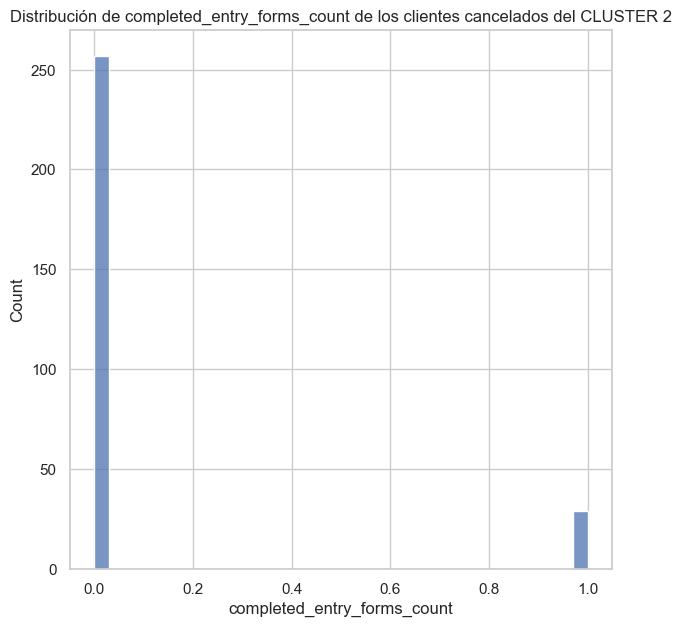

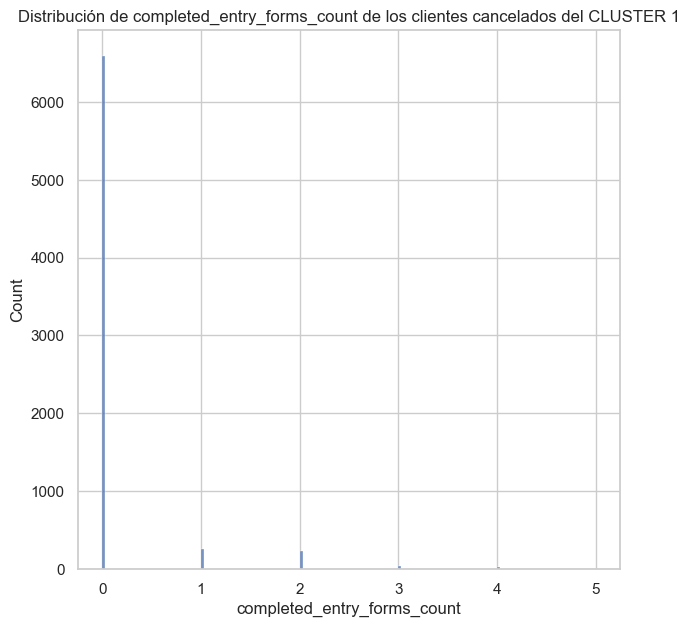

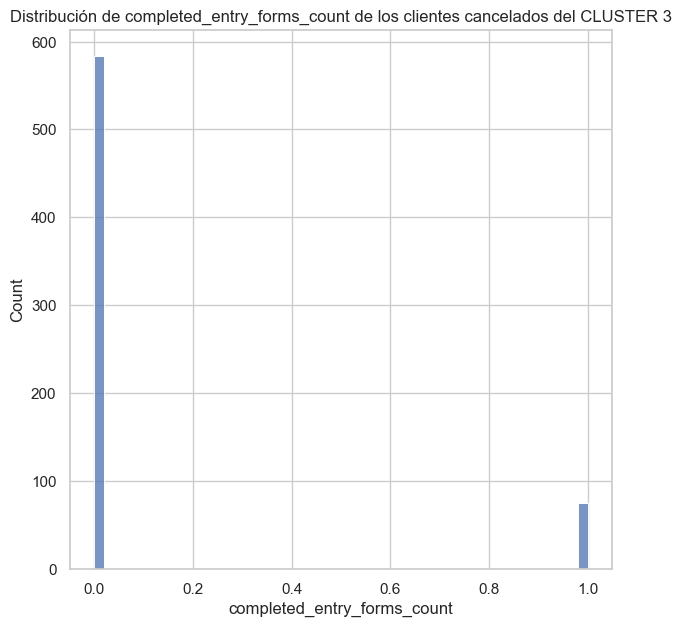

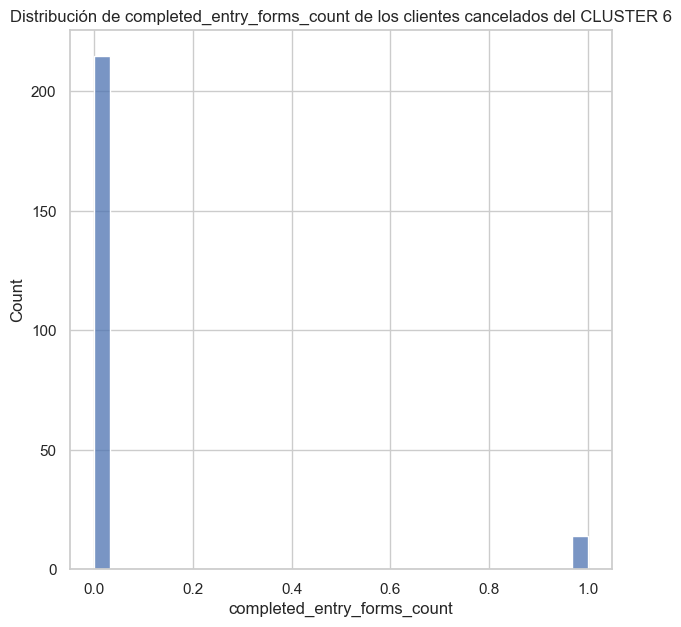

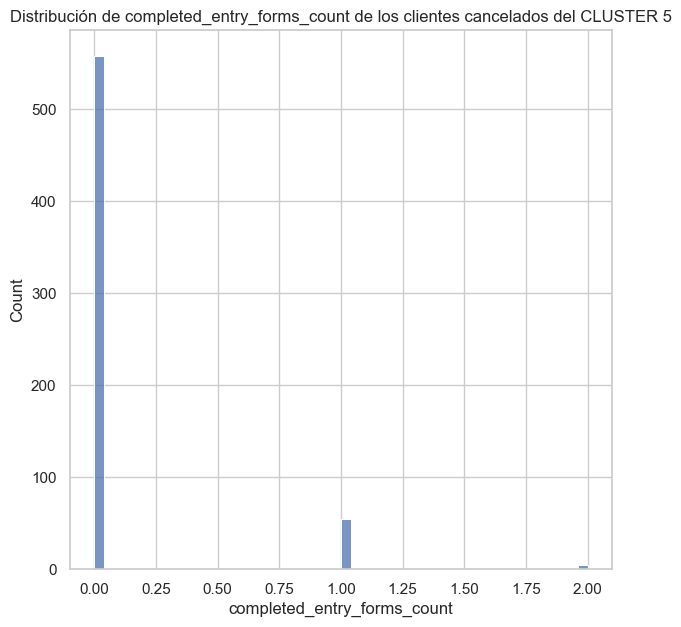

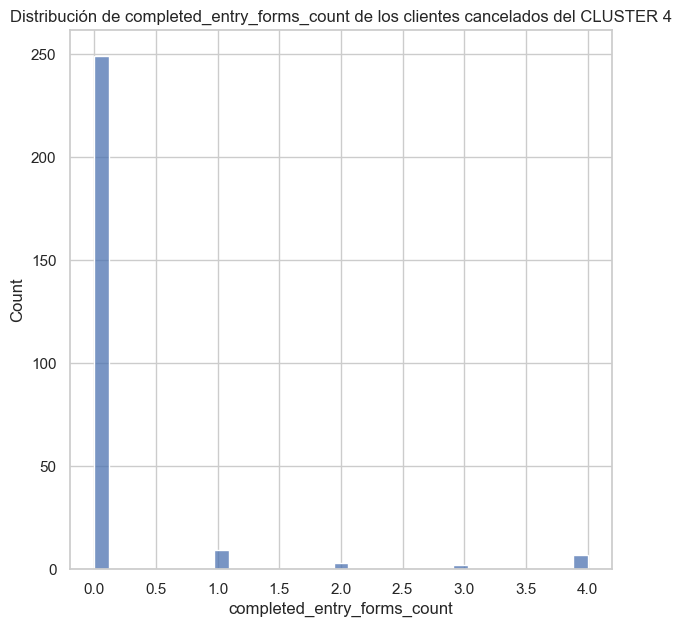

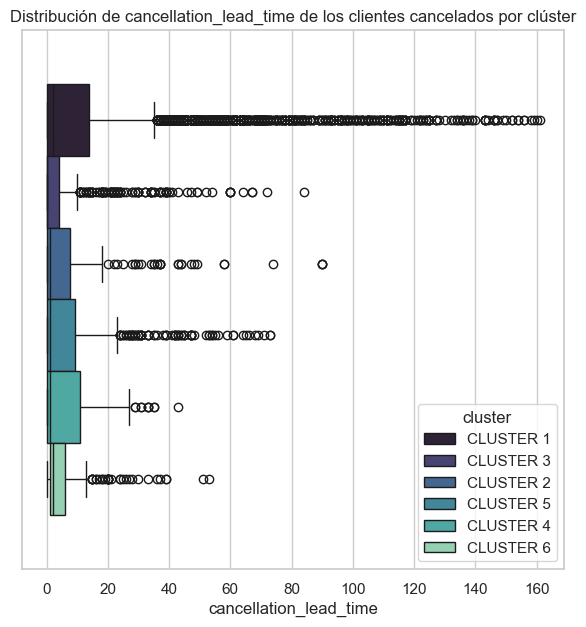

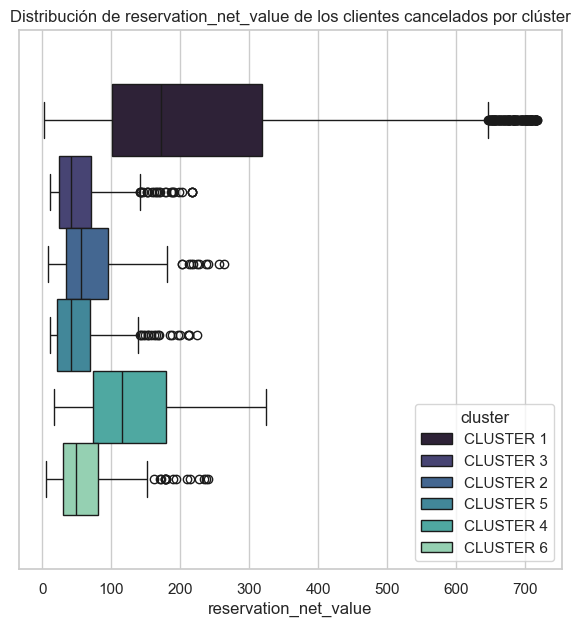

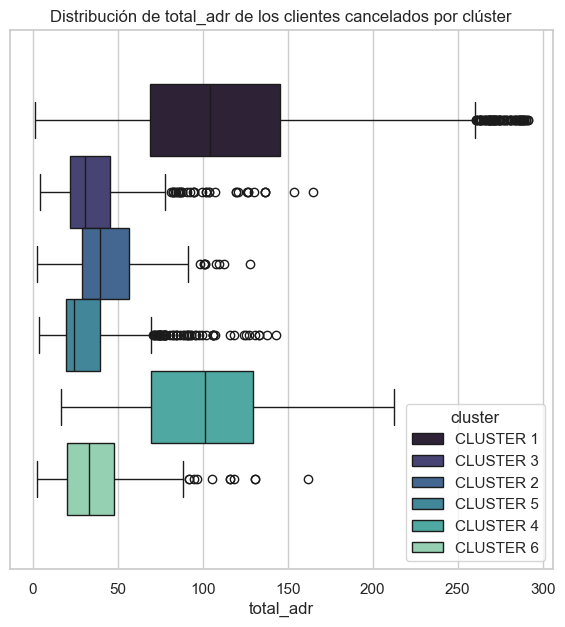

In [6]:
# VISUALIZACIONES

for var in var_int:
    for clust in clusters:
        f, ax = plt.subplots(figsize = (7,7))
        sns.set_theme(style="whitegrid")
        paleta_unificada = "mako"
        sns.histplot(data = cancelados[cancelados['cluster'] == clust], x = str(var), palette = paleta_unificada)
        plt.title(f'Distribución de {var} de los clientes cancelados del {clust}')
        plt.savefig(os.path.join('Graficos', 'Clusterizacion', f'histograma_{var}_cancelados_{clust}.png'))

for var in var_flo:
    f, ax = plt.subplots(figsize = (7,7))
    sns.set_theme(style="whitegrid")
    paleta_unificada = "mako"
    sns.boxplot(data = cancelados, x = str(var), hue = 'cluster', palette = paleta_unificada)
    plt.title(f'Distribución de {var} de los clientes cancelados por clúster')
    plt.savefig(os.path.join('Graficos', 'Clusterizacion', f'boxplot_{var}_cancelados_clusters.png'))



In [7]:
# # RESULTADOS

import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import os

df = pd.read_csv(os.path.join('Datos', 'Transformados', 'df_clustering.csv')) 
df["cluster_id"] = "C" + df["cluster"].astype(str).str.extract(r"(\d+)")[0].astype(int).astype(str)

def to01(x):
    if pd.isna(x): 
        return np.nan
    if isinstance(x, (bool, np.bool_)):
        return 1.0 if x else 0.0
    s = str(x).strip().lower()
    if s in ["true", "t", "1", "yes", "y"]:
        return 1.0
    if s in ["false", "f", "0", "no", "n"]:
        return 0.0
    return pd.to_numeric(x, errors="coerce")

for col in ["is_cancelled", "bought_products", "all_entry_forms_completed", "cliente_nuevo"]:
    if col in df.columns:
        df[col] = df[col].map(to01)

num_cols = [
    "lead_time", "lenght_of_stay", "total_adr", "reservation_net_value",
    "adult_count", "child_count", "product_count", "completed_entry_forms_count",
    "days_before_cancel", "cancellation_lead_time", "days_before_checkin"
]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

mean_cols = [c for c in df.columns if c.startswith("MEAN_")]
for c in mean_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

def pct(s): 
    return (s * 100).round(1)

cluster_sizes = df.groupby("cluster_id").size().rename("n").to_frame()
cluster_sizes["pct_total_%"] = pct(cluster_sizes["n"] / len(df))
cluster_sizes = cluster_sizes.sort_index().reset_index()

display(Markdown("## Tabla 1 — Tamaño de cluster (n y % del total)"))
display(cluster_sizes)

city_dist = df.pivot_table(
    index="cluster_id", columns="city", values="booked_at",
    aggfunc="count", fill_value=0
)
city_dist_pct = (city_dist.div(city_dist.sum(axis=1), axis=0) * 100).round(1)

dominant_city_tbl = pd.DataFrame({
    "dominant_city": city_dist_pct.idxmax(axis=1),
    "dominant_city_share_%": city_dist_pct.max(axis=1).round(1),
})
dominant_city_tbl["top5_cities_%"] = city_dist_pct.apply(
    lambda row: ", ".join(
        [f"{c}:{row[c]:.1f}%" for c in row.sort_values(ascending=False).head(5).index]
    ),
    axis=1
)
dominant_city_tbl = dominant_city_tbl.sort_index().reset_index()

display(Markdown("## Tabla 2 — Ciudad dominante y top-5 ciudades por cluster"))
display(dominant_city_tbl)

asset_dist = df.pivot_table(
    index="cluster_id", columns="asset_type", values="booked_at",
    aggfunc="count", fill_value=0
)
asset_dist_pct = (asset_dist.div(asset_dist.sum(axis=1), axis=0) * 100).round(1).reset_index()

display(Markdown("## Tabla 3 — Distribución de tipo de activo (asset_type) %"))
display(asset_dist_pct)

rate_dist = df.pivot_table(
    index="cluster_id", columns="rate_type", values="booked_at",
    aggfunc="count", fill_value=0
)
rate_dist_pct = (rate_dist.div(rate_dist.sum(axis=1), axis=0) * 100).round(1).reset_index()

display(Markdown("## Tabla 4 — Distribución de tipo de tarifa (rate_type) %"))
display(rate_dist_pct)

metrics = df.groupby("cluster_id").agg(
    lead_time_median=("lead_time", "median"),
    lead_time_mean=("lead_time", "mean"),
    los_mean=("lenght_of_stay", "mean"),
    los_median=("lenght_of_stay", "median"),
    adr_mean=("total_adr", "mean"),
    net_mean=("reservation_net_value", "mean"),
    cancel_rate=("is_cancelled", "mean"),
    days_before_cancel_mean=("days_before_cancel", "mean"),
    cancellation_lead_time_mean=("cancellation_lead_time", "mean"),
).round(2)

metrics["cancel_rate_%"] = (metrics["cancel_rate"] * 100).round(1)
metrics = metrics.drop(columns=["cancel_rate"]).sort_index().reset_index()

display(Markdown("## Tabla 5 — Métricas clave (lead time, estancia, ADR, neto, cancelación)"))
display(metrics)

behavior = df.groupby("cluster_id").agg(
    adults_mean=("adult_count", "mean"),
    children_mean=("child_count", "mean"),
    pct_with_children=("child_count", lambda s: (s.fillna(0) > 0).mean()),
    bought_products_rate=("bought_products", "mean"),
    products_per_booking=("product_count", "mean"),
    forms_completed_rate=("all_entry_forms_completed", "mean"),
    completed_forms_mean=("completed_entry_forms_count", "mean"),
    pct_new_customer=("cliente_nuevo", "mean"),
).round(3)

behavior["pct_with_children_%"] = (behavior["pct_with_children"] * 100).round(1)
behavior["bought_products_%"] = (behavior["bought_products_rate"] * 100).round(1)
behavior["forms_completed_%"] = (behavior["forms_completed_rate"] * 100).round(1)
behavior["pct_new_customer_%"] = (behavior["pct_new_customer"] * 100).round(1)

behavior = behavior.drop(columns=[
    "pct_with_children", "bought_products_rate", "forms_completed_rate", "pct_new_customer"
]).sort_index().reset_index()

display(Markdown("## Tabla 6 — Composición y comportamiento (niños, extras, formularios, cliente nuevo)"))
display(behavior)

origin_dist = df.pivot_table(
    index="cluster_id", columns="origin", values="booked_at",
    aggfunc="count", fill_value=0
)
origin_dist_pct = (origin_dist.div(origin_dist.sum(axis=1), axis=0) * 100).round(1).reset_index()

display(Markdown("## Tabla 7 — Distribución de origen/canal (origin) %"))
display(origin_dist_pct)

def top_otas(group, k=5):
    vc = group["travel_agency_name"].fillna("UNKNOWN").value_counts(normalize=True).head(k) * 100
    return ", ".join([f"{idx}:{val:.1f}%" for idx, val in vc.items()])

ota_top5 = (
    df.groupby("cluster_id", group_keys=False)
      .apply(top_otas)
      .rename("top5_travel_agency_%")
      .to_frame()
      .sort_index()
      .reset_index()
)

display(Markdown("## Tabla 8 — Top-5 agencias/canales (travel_agency_name) por cluster"))
display(ota_top5)

climate_cols = ["MEAN_tmin", "MEAN_tmax", "MEAN_tmed", "MEAN_sol", "MEAN_prec", "MEAN_hrMedia", "MEAN_racha"]
keep_climate = [c for c in climate_cols if c in df.columns]

climate_tbl = (
    df.groupby("cluster_id")[keep_climate]
      .mean()
      .round(2)
      .sort_index()
      .rename(columns={
          "MEAN_tmin": "tmin_media",
          "MEAN_tmax": "tmax_media",
          "MEAN_tmed": "tmedia",
          "MEAN_sol": "horas_sol",
          "MEAN_prec": "precipitacion",
          "MEAN_hrMedia": "humedad_relativa",
          "MEAN_racha": "racha_viento"
      })
      .reset_index()
)

display(Markdown("## Tabla 9 — Clima (t°, sol, precipitación, humedad, viento) por cluster"))
display(climate_tbl)

## Tabla 1 — Tamaño de cluster (n y % del total)

,cluster_id,n,pct_total_%
0,C1,30742,72.6
1,C2,2133,5.0
2,C3,2595,6.1
3,C4,1025,2.4
4,C5,3222,7.6
5,C6,2611,6.2


## Tabla 2 — Ciudad dominante y top-5 ciudades por cluster

,cluster_id,dominant_city,dominant_city_share_%,top5_cities_%
0,C1,VITORIA,29.2,"VITORIA:29.2%, MADRID:12.5%, DONOSTIA:11.3%, M..."
1,C2,DONOSTIA,100.0,"DONOSTIA:100.0%, BILBAO:0.0%, CORDOBA:0.0%, GR..."
2,C3,DONOSTIA,100.0,"DONOSTIA:100.0%, BILBAO:0.0%, CORDOBA:0.0%, GR..."
3,C4,VITORIA,100.0,"VITORIA:100.0%, BILBAO:0.0%, CORDOBA:0.0%, DON..."
4,C5,CORDOBA,99.5,"CORDOBA:99.5%, DONOSTIA:0.5%, BILBAO:0.0%, GRA..."
5,C6,CORDOBA,99.5,"CORDOBA:99.5%, DONOSTIA:0.5%, BILBAO:0.0%, GRA..."


## Tabla 3 — Distribución de tipo de activo (asset_type) %

...

C:\Users\danie\AppData\Local\Temp\ipykernel_23592\2536708392.py:145: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(top_otas)


## Tabla 8 — Top-5 agencias/canales (travel_agency_name) por cluster

,cluster_id,top5_travel_agency_%
0,C1,"Booking.com:43.2%, UNKNOWN:32.7%, Airbnb:5.8%,..."
1,C2,"Booking.com:58.2%, UNKNOWN:29.5%, Hostelworld ..."
2,C3,"Booking.com:56.3%, UNKNOWN:33.8%, Hostelworld ..."
3,C4,"Booking.com:76.5%, UNKNOWN:6.7%, Airbnb:5.7%, ..."
4,C5,"Booking.com:48.3%, Hostelworld Group:28.5%, UN..."
5,C6,"Booking.com:52.5%, Hostelworld Group:31.6%, UN..."


## Tabla 9 — Clima (t°, sol, precipitación, humedad, viento) por cluster

,cluster_id,tmin_media,tmax_media,tmedia,horas_sol,precipitacion,humedad_relativa,racha_viento
0,C1,10.39,22.64,16.52,7.25,1.63,65.08,10.75
1,C2,13.97,20.43,17.21,5.70,3.66,78.98,10.77
2,C3,13.27,19.64,16.45,5.55,3.86,78.33,11.13
3,C4,5.82,18.55,12.18,5.83,1.07,72.64,11.52
4,C5,11.27,27.03,19.15,9.86,0.92,55.37,8.72
5,C6,11.45,27.31,19.38,9.93,1.07,54.72,8.86
